<a href="https://colab.research.google.com/github/Maria-lin/F1-Analytics/blob/main/detection_anomalies_gab_v2_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1a237e 0%, #283593 50%, #1565c0 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
  <h1 style="color: white; font-size: 2.2em; margin: 0 0 10px 0;">🏧 Détection d'Anomalies — B</h1>
  <h3 style="color: #90CAF9; margin: 0 0 20px 0; font-weight: 300;">Identification automatique des comportements atypiques sur les Guichets Automatiques Bancaires</h3>
  <hr style="border-color: rgba(255,255,255,0.3); margin: 20px 0;"/>
  <table style="color: white; border-collapse: collapse; width: 100%;">
    <tr>
      <td style="padding: 4px 20px 4px 0;">👥 <b>Destinataires</b></td>
      <td style="color: #BBDEFB;">Experts métier · Responsables réseau GAB · Direction des risques</td>
    </tr>
    <tr>
      <td style="padding: 4px 20px 4px 0;">🎯 <b>Objectif</b></td>
      <td style="color: #BBDEFB;">Identifier automatiquement les GAB au comportement inhabituel, sans surveillance manuelle</td>
    </tr>
    <tr>
      <td style="padding: 4px 20px 4px 0;">🤖 <b>Approche</b></td>
      <td style="color: #BBDEFB;">Détection d'anomalies non supervisée (Isolation Forest) + Clustering comportemental (K-Means)</td>
    </tr>
    <tr>
      <td style="padding: 4px 20px 4px 0;">🏗️ <b>Environnement</b></td>
      <td style="color: #BBDEFB;">Dataiku DSS · Python 3.6+ · fiche_identite_gab_mensuel</td>
    </tr>
  </table>
</div>

In [1]:
-- ==============================================================================
-- FICHE IDENTITE GAB MENSUELLE  —  VERSION 3
-- INPUT  1 : tableretrait
-- INPUT  2 : table_ref_gab_finale
-- OUTPUT   : fiche_identite_gab_mensuelle
-- ==============================================================================
-- MODIFICATIONS APPLIQUÉES (structure originale conservée — pas de WITH)
-- [1] Parsing heure    : SUBSTR(LPAD(heure_operation,6,'0'),1,2) identique partout
-- [2] Séparation COS   : type_op distingue RETRAIT_COS / RETRAIT_HORSCOS
-- [3] Captures COS     : cap_nb et taux_capture_pct excluent les COS
--                        cap_cos_nb et taux_capture_cos_pct isolés en colonnes dédiées
-- [4] Motifs capture   : noms métier explicites + gestion variantes orthographiques
-- [5] Stats B hors-COS : moyennes/écarts-types calculés sur Autorisation-Retrait
--                        uniquement pour ne pas biaiser les z-scores
-- [6] HAVING           : exclut les mois sans retrait → supprime les 32 NULLs
-- [7] COALESCE         : type_gab_e_i → 'Inconnu' si absent du référentiel
-- [8] Z-scores         : calculés sur ret_nb_horscos (pas ret_nb total)
-- ==============================================================================
-- POINTS RESTANT À ARBITRER
-- [A] Mapping type_reseau → cat_reseau : à compléter avec vos codes internes
-- [B] Faut-il exclure les COS de ret_nb global ? Actuellement : COS + hors-COS
--     Si oui : remplacer IN ('RETRAIT_COS','RETRAIT_HORSCOS') par = 'RETRAIT_HORSCOS'
--     dans tous les agrégats de retrait de la sous-requête A
-- [C] Identification capture COS via cat_reseau = 'COS'. Si vous avez un code
--     type_reseau direct, l'ajouter dans la sous-requête B également
-- [D] Ajouter d'autres variantes orthographiques de motifs si nécessaire
-- ==============================================================================

SELECT

    gab_mois.num_automate,
    gab_mois.annee,
    gab_mois.mois,

    -- Référentiel GAB
    -- [7] COALESCE : évite les NULLs quand le GAB n'est pas dans le référentiel
    COALESCE(g.code_entite_de_gestion, 'Inconnu')   AS code_entite_de_gestion,
    COALESCE(g.`type-gab_e_i`, 'Inconnu')           AS type_gab_e_i,
    g.code_postale_emplacement,
    g.longitude,
    g.latitude,

    -- ── STATS RETRAITS (global COS + hors-COS) [2] ────────────────────────────
    gab_mois.ret_nb,
    gab_mois.ret_nb_jours_actifs,
    gab_mois.ret_montant_total,
    gab_mois.ret_montant_moyen,
    gab_mois.ret_montant_max,
    gab_mois.ret_montant_min,
    gab_mois.ret_montant_stddev,
    gab_mois.ret_nb_nuit,
    gab_mois.ret_nb_weekend,
    gab_mois.ret_nb_heure_pointe,
    gab_mois.ret_heure_moyenne,
    gab_mois.ret_pct_nuit,
    gab_mois.ret_pct_weekend,

    -- [2] Détail par sous-type de retrait (pour analyse ultérieure)
    gab_mois.ret_nb_cos,
    gab_mois.ret_nb_horscos,

    -- ── STATS CAPTURES hors-COS [3] ───────────────────────────────────────────
    gab_mois.cap_nb,
    gab_mois.cap_nb_nuit,
    gab_mois.cap_nb_weekend,
    gab_mois.cap_heure_moyenne,
    gab_mois.taux_capture_pct,

    -- [3] Captures COS isolées (ne participent pas aux z-scores)
    gab_mois.cap_cos_nb,
    gab_mois.taux_capture_cos_pct,

    -- ── MOTIFS DE CAPTURE [4] — noms métier explicites, hors COS ──────────────
    gab_mois.cap_nb_oubli_ou_incident_lecture,
    gab_mois.cap_nb_code_confidentiel_depasse,
    gab_mois.cap_nb_carte_perdue,
    gab_mois.cap_nb_carte_volee,
    gab_mois.cap_nb_autre_motif,
    gab_mois.cap_nb_motif_inconnu,

    -- ── AGRÉGATS PAR CATÉGORIE RÉSEAU ─────────────────────────────────────────
    gab_mois.nb_ope_reseau_franfinance,
    gab_mois.montant_reseau_franfinance,
    gab_mois.nb_ope_reseau_cb,
    gab_mois.montant_reseau_cb,
    gab_mois.nb_ope_reseau_trionis,
    gab_mois.montant_reseau_trionis,
    gab_mois.nb_ope_reseau_ppl,
    gab_mois.montant_reseau_ppl,
    gab_mois.nb_ope_reseau_mastercard,
    gab_mois.montant_reseau_mastercard,
    gab_mois.nb_ope_reseau_cofinoga,
    gab_mois.montant_reseau_cofinoga,
    gab_mois.nb_ope_reseau_interne,
    gab_mois.montant_reseau_interne,
    gab_mois.nb_ope_reseau_casino,
    gab_mois.montant_reseau_casino,
    gab_mois.nb_ope_reseau_accord,
    gab_mois.montant_reseau_accord,
    gab_mois.nb_ope_reseau_amex,
    gab_mois.montant_reseau_amex,
    gab_mois.nb_ope_reseau_visa,
    gab_mois.montant_reseau_visa,
    gab_mois.nb_ope_reseau_cos,
    gab_mois.montant_reseau_cos,
    gab_mois.nb_ope_reseau_jcb,
    gab_mois.montant_reseau_jcb,
    gab_mois.nb_ope_reseau_postepargne,
    gab_mois.montant_reseau_postepargne,
    gab_mois.nb_ope_reseau_carte_diners_et_discovery,
    gab_mois.montant_reseau_carte_diners_et_discovery,
    gab_mois.nb_ope_reseau_autres,
    gab_mois.montant_reseau_autres,

    -- ── Z-SCORES [5][8] ───────────────────────────────────────────────────────
    -- Volume comparé sur base hors-COS uniquement (référence homogène)
    ROUND((gab_mois.ret_nb_horscos     - per.avg_ret_nb)            / NULLIF(per.std_ret_nb,            0), 4) AS zscore_ret_nb,
    ROUND((gab_mois.ret_montant_total  - per.avg_ret_montant_total) / NULLIF(per.std_ret_montant_total, 0), 4) AS zscore_ret_montant_total,
    ROUND((gab_mois.ret_montant_moyen  - per.avg_ret_montant_moyen) / NULLIF(per.std_ret_montant_moyen, 0), 4) AS zscore_ret_montant_moyen,
    ROUND((gab_mois.ret_nb_nuit        - per.avg_ret_nb_nuit)       / NULLIF(per.std_ret_nb_nuit,       0), 4) AS zscore_ret_nb_nuit,
    ROUND((gab_mois.ret_pct_nuit       - per.avg_ret_pct_nuit)      / NULLIF(per.std_ret_pct_nuit,      0), 4) AS zscore_ret_pct_nuit,
    ROUND((gab_mois.ret_nb_weekend     - per.avg_ret_nb_weekend)    / NULLIF(per.std_ret_nb_weekend,    0), 4) AS zscore_ret_nb_weekend,
    -- [3] Capture hors-COS uniquement
    ROUND((gab_mois.cap_nb             - per.avg_cap_nb)            / NULLIF(per.std_cap_nb,            0), 4) AS zscore_cap_nb,
    ROUND((gab_mois.taux_capture_pct   - per.avg_taux_capture)      / NULLIF(per.std_taux_capture,      0), 4) AS zscore_taux_capture_pct,

    -- ── SCORE ANOMALIE GLOBAL [8] ─────────────────────────────────────────────
    (
        CASE WHEN ABS((gab_mois.ret_nb_horscos    - per.avg_ret_nb)            / NULLIF(per.std_ret_nb,            0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_montant_total - per.avg_ret_montant_total) / NULLIF(per.std_ret_montant_total, 0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_montant_moyen - per.avg_ret_montant_moyen) / NULLIF(per.std_ret_montant_moyen, 0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_nb_nuit       - per.avg_ret_nb_nuit)       / NULLIF(per.std_ret_nb_nuit,       0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_pct_nuit      - per.avg_ret_pct_nuit)      / NULLIF(per.std_ret_pct_nuit,      0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_nb_weekend    - per.avg_ret_nb_weekend)    / NULLIF(per.std_ret_nb_weekend,    0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.cap_nb            - per.avg_cap_nb)            / NULLIF(per.std_cap_nb,            0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.taux_capture_pct  - per.avg_taux_capture)      / NULLIF(per.std_taux_capture,      0)) > 2 THEN 1 ELSE 0 END
    ) AS nb_metriques_anormales,

    CASE WHEN (
        CASE WHEN ABS((gab_mois.ret_nb_horscos    - per.avg_ret_nb)            / NULLIF(per.std_ret_nb,            0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_montant_total - per.avg_ret_montant_total) / NULLIF(per.std_ret_montant_total, 0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_montant_moyen - per.avg_ret_montant_moyen) / NULLIF(per.std_ret_montant_moyen, 0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_nb_nuit       - per.avg_ret_nb_nuit)       / NULLIF(per.std_ret_nb_nuit,       0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_pct_nuit      - per.avg_ret_pct_nuit)      / NULLIF(per.std_ret_pct_nuit,      0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.ret_nb_weekend    - per.avg_ret_nb_weekend)    / NULLIF(per.std_ret_nb_weekend,    0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.cap_nb            - per.avg_cap_nb)            / NULLIF(per.std_cap_nb,            0)) > 2 THEN 1 ELSE 0 END +
        CASE WHEN ABS((gab_mois.taux_capture_pct  - per.avg_taux_capture)      / NULLIF(per.std_taux_capture,      0)) > 2 THEN 1 ELSE 0 END
    ) >= 2 THEN 1 ELSE 0 END AS flag_atypique


-- ════════════════════════════════════════════════════════════════════════════════
-- SOUS-REQUETE A : agregats par GAB + mois
-- ════════════════════════════════════════════════════════════════════════════════
FROM (
    SELECT
        num_automate,
        annee,
        mois,

        -- ── RETRAITS — volume global COS + hors-COS [2] ──────────────────────
        SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN 1       ELSE 0    END) AS ret_nb,
        COUNT(DISTINCT CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN date_iso END) AS ret_nb_jours_actifs,
        SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN montant  ELSE 0    END) AS ret_montant_total,
        AVG(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN montant  ELSE NULL END) AS ret_montant_moyen,
        MAX(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN montant  ELSE NULL END) AS ret_montant_max,
        MIN(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN montant  ELSE NULL END) AS ret_montant_min,
        STDDEV_POP(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN montant ELSE NULL END) AS ret_montant_stddev,
        SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN is_nuit    ELSE 0 END) AS ret_nb_nuit,
        SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN is_weekend ELSE 0 END) AS ret_nb_weekend,
        SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN is_hpointe ELSE 0 END) AS ret_nb_heure_pointe,
        AVG(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN heure      ELSE NULL END) AS ret_heure_moyenne,

        ROUND(
            SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN is_nuit ELSE 0 END) * 100.0
            / NULLIF(SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN 1 ELSE 0 END), 0)
        , 2) AS ret_pct_nuit,

        ROUND(
            SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN is_weekend ELSE 0 END) * 100.0
            / NULLIF(SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN 1 ELSE 0 END), 0)
        , 2) AS ret_pct_weekend,

        -- [2] Compteurs séparés COS / hors-COS
        SUM(CASE WHEN type_op = 'RETRAIT_COS'     THEN 1 ELSE 0 END) AS ret_nb_cos,
        SUM(CASE WHEN type_op = 'RETRAIT_HORSCOS' THEN 1 ELSE 0 END) AS ret_nb_horscos,

        -- ── CAPTURES hors-COS [3] ─────────────────────────────────────────────
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS' THEN 1       ELSE 0    END) AS cap_nb,
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS' THEN is_nuit    ELSE 0 END) AS cap_nb_nuit,
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS' THEN is_weekend ELSE 0 END) AS cap_nb_weekend,
        AVG(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS' THEN heure      ELSE NULL END) AS cap_heure_moyenne,

        -- taux_capture_pct = captures hors-COS / retraits hors-COS
        ROUND(
            SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS' THEN 1 ELSE 0 END) * 100.0
            / NULLIF(SUM(CASE WHEN type_op = 'RETRAIT_HORSCOS' THEN 1 ELSE 0 END), 0)
        , 4) AS taux_capture_pct,

        -- [3] Captures COS isolées
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau = 'COS' THEN 1 ELSE 0 END) AS cap_cos_nb,

        ROUND(
            SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau = 'COS' THEN 1 ELSE 0 END) * 100.0
            / NULLIF(SUM(CASE WHEN type_op = 'RETRAIT_COS' THEN 1 ELSE 0 END), 0)
        , 4) AS taux_capture_cos_pct,

        -- ── MOTIFS DE CAPTURE [4] — noms métier explicites, hors COS ──────────
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS'
                  AND motif_capture_norm = 'OUBLI_OU_INCIDENT_LECTURE'   THEN 1 ELSE 0 END) AS cap_nb_oubli_ou_incident_lecture,
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS'
                  AND motif_capture_norm = 'CODE_CONFIDENTIEL_DEPASSE'   THEN 1 ELSE 0 END) AS cap_nb_code_confidentiel_depasse,
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS'
                  AND motif_capture_norm = 'CARTE_PERDUE'                THEN 1 ELSE 0 END) AS cap_nb_carte_perdue,
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS'
                  AND motif_capture_norm = 'CARTE_VOLEE'                 THEN 1 ELSE 0 END) AS cap_nb_carte_volee,
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS'
                  AND motif_capture_norm = 'AUTRE_MOTIF'                 THEN 1 ELSE 0 END) AS cap_nb_autre_motif,
        SUM(CASE WHEN type_op = 'CAPTURE' AND cat_reseau != 'COS'
                  AND motif_capture_norm IS NULL                          THEN 1 ELSE 0 END) AS cap_nb_motif_inconnu,

        -- ── AGRÉGATS PAR CATÉGORIE RÉSEAU ─────────────────────────────────────
        SUM(CASE WHEN cat_reseau = 'Franfinance'             THEN 1       ELSE 0 END) AS nb_ope_reseau_franfinance,
        SUM(CASE WHEN cat_reseau = 'Franfinance'             THEN montant ELSE 0 END) AS montant_reseau_franfinance,
        SUM(CASE WHEN cat_reseau = 'CB'                      THEN 1       ELSE 0 END) AS nb_ope_reseau_cb,
        SUM(CASE WHEN cat_reseau = 'CB'                      THEN montant ELSE 0 END) AS montant_reseau_cb,
        SUM(CASE WHEN cat_reseau = 'Trionis'                 THEN 1       ELSE 0 END) AS nb_ope_reseau_trionis,
        SUM(CASE WHEN cat_reseau = 'Trionis'                 THEN montant ELSE 0 END) AS montant_reseau_trionis,
        SUM(CASE WHEN cat_reseau = 'PPL'                     THEN 1       ELSE 0 END) AS nb_ope_reseau_ppl,
        SUM(CASE WHEN cat_reseau = 'PPL'                     THEN montant ELSE 0 END) AS montant_reseau_ppl,
        SUM(CASE WHEN cat_reseau = 'Mastercard'              THEN 1       ELSE 0 END) AS nb_ope_reseau_mastercard,
        SUM(CASE WHEN cat_reseau = 'Mastercard'              THEN montant ELSE 0 END) AS montant_reseau_mastercard,
        SUM(CASE WHEN cat_reseau = 'Cofinoga'                THEN 1       ELSE 0 END) AS nb_ope_reseau_cofinoga,
        SUM(CASE WHEN cat_reseau = 'Cofinoga'                THEN montant ELSE 0 END) AS montant_reseau_cofinoga,
        SUM(CASE WHEN cat_reseau = 'Interne'                 THEN 1       ELSE 0 END) AS nb_ope_reseau_interne,
        SUM(CASE WHEN cat_reseau = 'Interne'                 THEN montant ELSE 0 END) AS montant_reseau_interne,
        SUM(CASE WHEN cat_reseau = 'Casino'                  THEN 1       ELSE 0 END) AS nb_ope_reseau_casino,
        SUM(CASE WHEN cat_reseau = 'Casino'                  THEN montant ELSE 0 END) AS montant_reseau_casino,
        SUM(CASE WHEN cat_reseau = 'Accord'                  THEN 1       ELSE 0 END) AS nb_ope_reseau_accord,
        SUM(CASE WHEN cat_reseau = 'Accord'                  THEN montant ELSE 0 END) AS montant_reseau_accord,
        SUM(CASE WHEN cat_reseau = 'Amex'                    THEN 1       ELSE 0 END) AS nb_ope_reseau_amex,
        SUM(CASE WHEN cat_reseau = 'Amex'                    THEN montant ELSE 0 END) AS montant_reseau_amex,
        SUM(CASE WHEN cat_reseau = 'Visa'                    THEN 1       ELSE 0 END) AS nb_ope_reseau_visa,
        SUM(CASE WHEN cat_reseau = 'Visa'                    THEN montant ELSE 0 END) AS montant_reseau_visa,
        SUM(CASE WHEN cat_reseau = 'COS'                     THEN 1       ELSE 0 END) AS nb_ope_reseau_cos,
        SUM(CASE WHEN cat_reseau = 'COS'                     THEN montant ELSE 0 END) AS montant_reseau_cos,
        SUM(CASE WHEN cat_reseau = 'JCB'                     THEN 1       ELSE 0 END) AS nb_ope_reseau_jcb,
        SUM(CASE WHEN cat_reseau = 'JCB'                     THEN montant ELSE 0 END) AS montant_reseau_jcb,
        SUM(CASE WHEN cat_reseau = 'PostEpargne'             THEN 1       ELSE 0 END) AS nb_ope_reseau_postepargne,
        SUM(CASE WHEN cat_reseau = 'PostEpargne'             THEN montant ELSE 0 END) AS montant_reseau_postepargne,
        SUM(CASE WHEN cat_reseau = 'Carte Diners et Discovery' THEN 1       ELSE 0 END) AS nb_ope_reseau_carte_diners_et_discovery,
        SUM(CASE WHEN cat_reseau = 'Carte Diners et Discovery' THEN montant ELSE 0 END) AS montant_reseau_carte_diners_et_discovery,
        SUM(CASE WHEN cat_reseau NOT IN (
                    'Franfinance','CB','Trionis','PPL','Mastercard',
                    'Cofinoga','Interne','Casino','Accord','Amex',
                    'Visa','COS','JCB','PostEpargne','Carte Diners et Discovery'
                ) OR cat_reseau IS NULL THEN 1       ELSE 0 END) AS nb_ope_reseau_autres,
        SUM(CASE WHEN cat_reseau NOT IN (
                    'Franfinance','CB','Trionis','PPL','Mastercard',
                    'Cofinoga','Interne','Casino','Accord','Amex',
                    'Visa','COS','JCB','PostEpargne','Carte Diners et Discovery'
                ) OR cat_reseau IS NULL THEN montant ELSE 0 END) AS montant_reseau_autres

    FROM (
        -- ════════════════════════════════════════════════════════════════════
        -- SOUS-REQUETE A1 : parsing + flags + classification
        -- ════════════════════════════════════════════════════════════════════
        SELECT
            num_automate,

            CONCAT(
                SUBSTR(date_operation, 5, 4), '-',
                SUBSTR(date_operation, 3, 2), '-',
                SUBSTR(date_operation, 1, 2)
            ) AS date_iso,

            CAST(SUBSTR(date_operation, 5, 4) AS INT) AS annee,
            CAST(SUBSTR(date_operation, 3, 2) AS INT) AS mois,

            -- [1] heure_operation = '090827' (HHMMSS) → on prend les 2 premiers caractères
            CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) AS heure,

            CAST(REGEXP_REPLACE(montant_ope, ',', '.') AS DOUBLE) AS montant,

            -- [2] Séparation COS / hors-COS
            --     'Retrait'              = retrait carte COS (carte maison)
            --     'Autorisation-Retrait' = retrait interbancaire (hors COS)
            CASE
                WHEN lib_ope = 'Retrait'              THEN 'RETRAIT_COS'
                WHEN lib_ope = 'Autorisation-Retrait' THEN 'RETRAIT_HORSCOS'
                WHEN lib_ope = 'Capture de Carte'     THEN 'CAPTURE'
            END AS type_op,

            -- [4] Motif de capture normalisé avec gestion des variantes orthographiques
            CASE
                WHEN UPPER(TRIM(lib_motif_capture_capture_carte)) IN (
                    'OUBLI CARTE',
                    'OUBLI DE CARTE',
                    'INCIDENT LECTURE DE CARTE',
                    'INCIDENT LECTURE CARTE'
                ) THEN 'OUBLI_OU_INCIDENT_LECTURE'

                WHEN UPPER(TRIM(lib_motif_capture_capture_carte)) IN (
                    'NOMBRE ESSAI CODE CONFIDENTIEL DEPASSE',
                    'NOMBRE ESSAIS CODE CONFIDENTIEL DEPASSE',
                    'NOMBRE ESSAI CODE DEPASSE',
                    'NB ESSAI CODE CONFIDENTIEL DEPASSE',
                    'CODE CONFIDENTIEL DEPASSE'
                ) THEN 'CODE_CONFIDENTIEL_DEPASSE'

                WHEN UPPER(TRIM(lib_motif_capture_capture_carte)) IN (
                    'CARTE PERDUE',
                    'CARTE DECLAREE PERDUE'
                ) THEN 'CARTE_PERDUE'

                WHEN UPPER(TRIM(lib_motif_capture_capture_carte)) IN (
                    'CARTE VOLEE',
                    'CARTE VOLÉE',
                    'CARTE DECLAREE VOLEE',
                    'CARTE DÉCLARÉE VOLÉE',
                    'VOL DE CARTE'
                ) THEN 'CARTE_VOLEE'

                WHEN lib_motif_capture_capture_carte IS NOT NULL
                THEN 'AUTRE_MOTIF'

                ELSE NULL
            END AS motif_capture_norm,

            -- [1] Flags horaires — même parsing LPAD partout
            CASE
                WHEN CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) >= 22
                  OR CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) <  6
                THEN 1 ELSE 0
            END AS is_nuit,

            CASE
                WHEN DAYOFWEEK(CONCAT(
                    SUBSTR(date_operation, 5, 4), '-',
                    SUBSTR(date_operation, 3, 2), '-',
                    SUBSTR(date_operation, 1, 2)
                )) IN (1, 7)
                THEN 1 ELSE 0
            END AS is_weekend,

            CASE
                WHEN CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) BETWEEN  8 AND  9
                  OR CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) BETWEEN 12 AND 13
                  OR CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) BETWEEN 17 AND 18
                THEN 1 ELSE 0
            END AS is_hpointe,

            -- [A] MAPPING RÉSEAU — À COMPLÉTER AVEC VOS CODES INTERNES
            -- Décommenter et adapter les WHEN avec vos vrais codes type_reseau
            -- Le code COS est critique pour le filtre [3] : bien le renseigner
            CASE
                -- WHEN type_reseau = '06' THEN 'Franfinance'
                -- WHEN type_reseau = '00' THEN 'CB'
                -- WHEN type_reseau = '10' THEN 'Trionis'
                -- WHEN type_reseau = '03' THEN 'PPL'
                -- WHEN type_reseau = '02' THEN 'Mastercard'
                -- WHEN type_reseau = '09' THEN 'Cofinoga'
                -- WHEN type_reseau = '01' THEN 'Interne'
                -- WHEN type_reseau = '11' THEN 'Casino'
                -- WHEN type_reseau = '12' THEN 'Accord'
                -- WHEN type_reseau = '13' THEN 'Amex'
                -- WHEN type_reseau = '04' THEN 'Visa'
                -- WHEN type_reseau = '05' THEN 'COS'   ← CRITIQUE pour le filtre [3]
                -- WHEN type_reseau = '07' THEN 'JCB'
                -- WHEN type_reseau = '08' THEN 'PostEpargne'
                -- WHEN type_reseau = '14' THEN 'Carte Diners et Discovery'
                ELSE NULL
            END AS cat_reseau

        FROM tableretrait
        WHERE lib_ope IN ('Retrait', 'Autorisation-Retrait', 'Capture de Carte')
          -- Filtre qualité : exclure les montants nuls ou négatifs sur les retraits
          AND (
               lib_ope = 'Capture de Carte'
            OR CAST(REGEXP_REPLACE(montant_ope, ',', '.') AS DOUBLE) > 0
          )

    ) ops_enrichies
    GROUP BY num_automate, annee, mois
    -- [6] Exclure les mois sans aucun retrait → élimine les 32 NULLs
    --     sur ret_montant_*, ret_heure_moyenne, ret_pct_*, taux_capture_pct
    HAVING SUM(CASE WHEN type_op IN ('RETRAIT_COS','RETRAIT_HORSCOS') THEN 1 ELSE 0 END) > 0

) gab_mois


-- ════════════════════════════════════════════════════════════════════════════════
-- SOUS-REQUETE B : moyennes + ecarts-types cross-GAB par periode [5]
-- Calculé uniquement sur Autorisation-Retrait (hors-COS)
-- pour ne pas biaiser la référence réseau avec le volume COS
-- ════════════════════════════════════════════════════════════════════════════════
LEFT JOIN (
    SELECT
        annee,
        mois,
        AVG(ret_nb_horscos)           AS avg_ret_nb,
        STDDEV_POP(ret_nb_horscos)    AS std_ret_nb,
        AVG(ret_montant_total)        AS avg_ret_montant_total,
        STDDEV_POP(ret_montant_total) AS std_ret_montant_total,
        AVG(ret_montant_moyen)        AS avg_ret_montant_moyen,
        STDDEV_POP(ret_montant_moyen) AS std_ret_montant_moyen,
        AVG(ret_nb_nuit)              AS avg_ret_nb_nuit,
        STDDEV_POP(ret_nb_nuit)       AS std_ret_nb_nuit,
        AVG(ret_pct_nuit)             AS avg_ret_pct_nuit,
        STDDEV_POP(ret_pct_nuit)      AS std_ret_pct_nuit,
        AVG(ret_nb_weekend)           AS avg_ret_nb_weekend,
        STDDEV_POP(ret_nb_weekend)    AS std_ret_nb_weekend,
        -- [3] Moyennes de capture sur base hors-COS
        -- [C] Pour filtrer aussi les captures COS ici, ajouter dans les CASE WHEN
        --     la condition AND type_reseau != '<votre_code_COS>'
        AVG(cap_nb)                   AS avg_cap_nb,
        STDDEV_POP(cap_nb)            AS std_cap_nb,
        AVG(taux_capture_pct)         AS avg_taux_capture,
        STDDEV_POP(taux_capture_pct)  AS std_taux_capture

    FROM (
        SELECT
            num_automate,
            CAST(SUBSTR(date_operation, 5, 4) AS INT) AS annee,
            CAST(SUBSTR(date_operation, 3, 2) AS INT) AS mois,

            -- [5] Retraits hors-COS uniquement (Autorisation-Retrait)
            SUM(CASE WHEN lib_ope = 'Autorisation-Retrait' THEN 1 ELSE 0 END) AS ret_nb_horscos,

            SUM(CASE WHEN lib_ope = 'Autorisation-Retrait'
                     THEN CAST(REGEXP_REPLACE(montant_ope, ',', '.') AS DOUBLE)
                     ELSE 0 END) AS ret_montant_total,

            AVG(CASE WHEN lib_ope = 'Autorisation-Retrait'
                     THEN CAST(REGEXP_REPLACE(montant_ope, ',', '.') AS DOUBLE)
                     ELSE NULL END) AS ret_montant_moyen,

            -- [1] Parsing heure identique à A1
            SUM(CASE
                WHEN lib_ope = 'Autorisation-Retrait'
                 AND (CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) >= 22
                   OR CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) <  6)
                THEN 1 ELSE 0
            END) AS ret_nb_nuit,

            ROUND(
                SUM(CASE
                    WHEN lib_ope = 'Autorisation-Retrait'
                     AND (CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) >= 22
                       OR CAST(SUBSTR(LPAD(heure_operation, 6, '0'), 1, 2) AS INT) <  6)
                    THEN 1 ELSE 0
                END) * 100.0
                / NULLIF(SUM(CASE WHEN lib_ope = 'Autorisation-Retrait' THEN 1 ELSE 0 END), 0)
            , 2) AS ret_pct_nuit,

            SUM(CASE
                WHEN lib_ope = 'Autorisation-Retrait'
                 AND DAYOFWEEK(CONCAT(
                        SUBSTR(date_operation, 5, 4), '-',
                        SUBSTR(date_operation, 3, 2), '-',
                        SUBSTR(date_operation, 1, 2)
                     )) IN (1, 7)
                THEN 1 ELSE 0
            END) AS ret_nb_weekend,

            -- Captures : toutes (voir [C] pour affiner si code COS disponible)
            SUM(CASE WHEN lib_ope = 'Capture de Carte' THEN 1 ELSE 0 END) AS cap_nb,

            ROUND(
                SUM(CASE WHEN lib_ope = 'Capture de Carte' THEN 1 ELSE 0 END) * 100.0
                / NULLIF(SUM(CASE WHEN lib_ope = 'Autorisation-Retrait' THEN 1 ELSE 0 END), 0)
            , 4) AS taux_capture_pct

        FROM tableretrait
        WHERE lib_ope IN ('Retrait', 'Autorisation-Retrait', 'Capture de Carte')
          AND (lib_ope = 'Capture de Carte'
            OR CAST(REGEXP_REPLACE(montant_ope, ',', '.') AS DOUBLE) > 0)
        GROUP BY
            num_automate,
            CAST(SUBSTR(date_operation, 5, 4) AS INT),
            CAST(SUBSTR(date_operation, 3, 2) AS INT)
        -- [6] Exclure les GAB-mois sans Autorisation-Retrait de la base de référence
        HAVING SUM(CASE WHEN lib_ope = 'Autorisation-Retrait' THEN 1 ELSE 0 END) > 0

    ) agg_pour_stats
    GROUP BY annee, mois

) per
    ON  gab_mois.annee = per.annee
    AND gab_mois.mois  = per.mois


-- ════════════════════════════════════════════════════════════════════════════════
-- JOINTURE REFERENTIEL GAB
-- ════════════════════════════════════════════════════════════════════════════════
LEFT JOIN table_ref_gab_finale g
    ON gab_mois.num_automate = g.num_automate
;


SyntaxError: invalid character '—' (U+2014) (248622784.py, line 2)

<div style="background: #E8F5E9; border-left: 5px solid #2E7D32; padding: 16px 20px; border-radius: 6px; margin: 10px 0;">
  <h3 style="color: #1B5E20; margin: 0 0 10px 0;">📋 Guide de lecture du notebook</h3>
  <p style="margin: 5px 0;">Ce notebook se lit de haut en bas et est structuré en <b>4 grandes étapes</b> :</p>
  <ol style="margin: 8px 0; padding-left: 20px;">
    <li style="margin: 4px 0;"><b>1 → 3</b> · Chargement, qualité des données et enrichissement des variables</li>
    <li style="margin: 4px 0;"><b>4 → 5</b> · Analyse exploratoire : comprendre le comportement normal du réseau</li>
    <li style="margin: 4px 0;"><b>6 → 8</b> · Modélisation : clustering + détection d'anomalies + explication</li>
    <li style="margin: 4px 0;"><b>9 → 11</b> · Vue annuelle, carte géographique et synthèse opérationnelle</li>
  </ol>
  <p style="margin: 8px 0 0 0; color: #2E7D32;">💡 <b>Les cellules commentaires (fond coloré) sont destinées aux équipes métier. Les cellules code peuvent être ignorées.</b></p>
</div>

---
## 1. 🏦 Contexte Métier — Pourquoi surveiller les GAB ?

Un **Guichet Automatique Bancaire** est bien plus qu'une machine à billets.  
Chaque mois, il génère des **centaines d'opérations** formant une empreinte comportementale unique.

| 🟢 GAB Normal | 🔴 GAB Atypique — Signaux d'alerte |
|---|---|
| Volume stable, cohérent avec la localisation | Pic de retraits isolé, hors saisonnalité |
| Taux de capture de carte bas (< 1%) | Taux de capture élevé → panne ou fraude |
| Activité diurne, rythmée semaine/weekend | Activité nocturne ou weekend anormalement haute |
| Mix réseau de cartes diversifié | Concentration excessive sur un seul réseau |
| Montants moyens dans la norme | Montants extrêmes → gros retraits suspects |

### Pourquoi un modèle plutôt qu'une surveillance manuelle ?

> *« Les anomalies évidentes, on les voit déjà. Le modèle, lui, détecte les combinaisons subtiles de signaux faibles. »*

**Ce que le modèle voit que l'humain ne peut pas voir :**
- Un GAB avec montant moyen légèrement élevé **ET** taux capture légèrement haut **ET** activité nocturne légèrement supérieure → **anomalie invisible à l'œil nu**
- Surveillance simultanée de **tous les GAB** du réseau, chaque mois, sans fatigue
- Résultat **reproductible et documenté**, indépendant de l'expertise individuelle

---
## 2. ⚙️ Imports et Configuration

In [ ]:
# ── Librairies standards ───────────────────────────────────────────────────────
from __future__ import print_function, division
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_OK = True
except ImportError:
    PLOTLY_OK = False
    print('⚠️  Plotly non disponible — les cartes seront remplacées par matplotlib.')

# ── Machine Learning ───────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

# ── Affichage notebook ─────────────────────────────────────────────────────────
from IPython.display import display, HTML

# ── Charte graphique banque ────────────────────────────────────────────────────
BLEU_BANQUE      = '#1565C0'
BLEU_CLAIR       = '#42A5F5'
ROUGE_ALERTE     = '#C62828'
ORANGE_VIGILANCE = '#E65100'
VERT_NORMAL      = '#2E7D32'
GRIS_FOND        = '#ECEFF1'
COULEUR_CLUSTERS = ['#1565C0','#2E7D32','#E65100','#6A1B9A','#00838F']

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#FAFAFA',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})

print('✅ Environnement initialisé — Python', __import__('sys').version.split()[0])
print('   Pandas', pd.__version__, '· NumPy', np.__version__, '· Scikit-learn', __import__('sklearn').__version__)

✅ Environnement initialisé — Python 3.12.13
   Pandas 2.2.2 · NumPy 2.0.2 · Scikit-learn 1.6.1


---
## 3. 📂 Chargement des Données

Le dataset **`fiche_identite_gab_mensuel`** contient **une ligne par GAB et par mois**.  
Chaque ligne résume l'activité complète d'un automate sur la période (retraits, captures, réseaux, horaires…).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHARGEMENT — Décommenter la ligne correspondant à votre environnement
# ═══════════════════════════════════════════════════════════════════════════════

# ── Option 1 : Dataiku (recommandé en production) ──────────────────────────────
# import dataiku
# df_raw = dataiku.Dataset('fiche_identite_gab_mensuel').get_dataframe()

# ── Option 2 : Fichier CSV local ───────────────────────────────────────────────
# df_raw = pd.read_csv('fiche_identite_gab_mensuel.csv')

# ── Option 3 : Simulation réaliste (démonstration) ────────────────────────────
np.random.seed(42)

RESEAUX = ['CB','Visa','Mastercard','Interne','Franfinance','Accord',
           'PostEpargne','JCB','Trionis','PPL','Configona','COS',
           'Casino','Diners_et_Discovery','autres']

def simuler_gab_normal(n, prefix='GAB'):
    d = {
        'num_automate'       : ['{0}_{1:04d}'.format(prefix, i) for i in range(n)],
        'annee'              : np.random.choice([2024, 2025], n),
        'mois'               : np.random.randint(1, 13, n),
        'code_entite_de_gestion': np.random.choice(['ENT_A','ENT_B','ENT_C','ENT_D'], n),
        'type_gab_e_i'       : np.random.choice(['Interne','Externe'], n, p=[0.35, 0.65]),
        'code_postale_emplacement': np.random.choice(['75001','69001','13001','33000','31000','59000','06000','67000'], n),
        'longitude'          : np.random.uniform(-4.5, 8.2, n),
        'latitude'           : np.random.uniform(42.3, 51.1, n),
        'ret_nb'             : np.random.normal(820, 140, n).clip(50),
        'ret_nb_jours_actifs': np.random.randint(18, 31, n),
        'ret_montant_total'  : np.random.normal(125000, 22000, n).clip(5000),
        'ret_montant_moyen'  : np.random.normal(152, 28, n).clip(40),
        'ret_montant_max'    : np.random.normal(500,  75, n).clip(150),
        'ret_montant_min'    : np.random.normal(20,    8, n).clip(10),
        'ret_montant_stddev' : np.random.normal(62,   14, n).clip(5),
        'ret_nb_nuit'        : np.random.normal(78,   22, n).clip(0),
        'ret_nb_weekend'     : np.random.normal(185,  38, n).clip(0),
        'ret_nb_heure_pointe': np.random.normal(220,  45, n).clip(0),
        'ret_heure_moyenne'  : np.random.normal(12.8, 1.2, n).clip(6, 22),
        'ret_pct_nuit'       : np.random.normal(9.5,  2.8, n).clip(0, 60),
        'ret_pct_weekend'    : np.random.normal(22.5, 4.5, n).clip(0, 70),
        'cap_nb'             : np.random.poisson(3.5, n),
        'cap_nb_nuit'        : np.random.poisson(0.4, n),
        'cap_nb_weekend'     : np.random.poisson(0.8, n),
        'cap_heure_moyenne'  : np.random.normal(13.0, 2.0, n).clip(6, 22),
        'taux_capture_pct'   : np.random.normal(0.45, 0.28, n).clip(0),
        'cap_nb_motif1'      : np.random.poisson(1.2, n),
        'cap_nb_motif2'      : np.random.poisson(0.8, n),
        'cap_nb_motif3'      : np.random.poisson(0.6, n),
        'cap_nb_motif4'      : np.random.poisson(0.4, n),
        'cap_nb_motif5'      : np.random.poisson(0.3, n),
        'cap_nb_motif6'      : np.random.poisson(0.2, n),
        'zscore_ret_nb'          : np.random.normal(0, 0.7, n),
        'zscore_ret_montant_total': np.random.normal(0, 0.7, n),
        'zscore_ret_montant_moyen': np.random.normal(0, 0.7, n),
        'zscore_ret_nb_nuit'     : np.random.normal(0, 0.7, n),
        'zscore_pct_nuit'        : np.random.normal(0, 0.7, n),
        'zscore_ret_nb_weekend'  : np.random.normal(0, 0.7, n),
        'zscore_cap_nb'          : np.random.normal(0, 0.7, n),
        'zscore_taux_capture'    : np.random.normal(0, 0.7, n),
        'nb_metriques_anormales' : np.random.choice([0,0,0,1,1,2], n),
        'flag_atypique'          : np.zeros(n, dtype=int),
    }
    for reseau in RESEAUX:
        base = {'CB':350,'Visa':180,'Mastercard':120,'Interne':80,'Franfinance':30,
                'Accord':25,'PostEpargne':5,'JCB':4,'Trionis':15,'PPL':12,
                'Configona':8,'COS':6,'Casino':10,'Diners_et_Discovery':3,'autres':10}[reseau]
        d['nb_ope_reseau_{0}'.format(reseau)]       = np.random.normal(base, base*0.25, n).clip(0)
        d['montant_reseau_{0}'.format(reseau)]       = np.random.normal(base*155, base*40, n).clip(0)
    return pd.DataFrame(d)

def injecter_anomalies(df_n, n_anom=40):
    """Génère des GAB atypiques avec différents profils d'anomalie."""
    types_anom = {
        'CAPTURE_FRAUDE' : 10,
        'ACTIVITE_NUIT'  : 10,
        'VOLUME_EXCES'   : 10,
        'MONTANT_ANORMAL': 10,
    }
    frames = [df_n]
    idx = 0
    for typ, nb in types_anom.items():
        d = df_n.sample(nb, replace=True).copy()
        d['num_automate'] = ['ANOM_{0}_{1:03d}'.format(typ[:3], i+idx) for i in range(nb)]
        d['flag_atypique'] = 1
        d['nb_metriques_anormales'] = np.random.randint(2, 6, nb)
        if typ == 'CAPTURE_FRAUDE':
            d['taux_capture_pct']    = np.random.normal(9.5, 2.5, nb).clip(4)
            d['cap_nb']              = np.random.normal(65,  15, nb).clip(20).astype(int)
            d['zscore_taux_capture'] = np.random.normal(4.2, 0.8, nb)
            d['zscore_cap_nb']       = np.random.normal(3.8, 0.7, nb)
        elif typ == 'ACTIVITE_NUIT':
            d['ret_pct_nuit']        = np.random.normal(42,   8, nb).clip(25)
            d['ret_nb_nuit']         = np.random.normal(380,  60, nb).clip(150).astype(int)
            d['cap_nb_nuit']         = np.random.normal(15,   4, nb).clip(5).astype(int)
            d['zscore_pct_nuit']     = np.random.normal(4.5,  0.9, nb)
            d['zscore_ret_nb_nuit']  = np.random.normal(3.9,  0.8, nb)
        elif typ == 'VOLUME_EXCES':
            d['ret_nb']              = np.random.normal(2200, 300, nb).clip(1500)
            d['ret_montant_total']   = np.random.normal(380000, 55000, nb).clip(200000)
            d['zscore_ret_nb']       = np.random.normal(4.8,  0.9, nb)
            d['zscore_ret_montant_total'] = np.random.normal(4.2, 0.8, nb)
        elif typ == 'MONTANT_ANORMAL':
            d['ret_montant_moyen']   = np.random.normal(480,  80, nb).clip(280)
            d['ret_montant_max']     = np.random.normal(1500, 250, nb).clip(800)
            d['zscore_ret_montant_moyen'] = np.random.normal(4.0, 0.8, nb)
        idx += nb
        frames.append(d)
    return pd.concat(frames, ignore_index=True)

df_normal = simuler_gab_normal(440)
df_raw    = injecter_anomalies(df_normal, n_anom=40)
df_raw    = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)

print('✅ Dataset chargé : {0} lignes × {1} colonnes'.format(df_raw.shape[0], df_raw.shape[1]))
print('   → {0} GAB distincts · {1} période(s)'.format(
    df_raw['num_automate'].nunique(),
    df_raw.groupby(['annee','mois']).ngroups
))
df_raw.head(3)

✅ Dataset chargé : 480 lignes × 72 colonnes
   → 480 GAB distincts · 24 période(s)


,num_automate,annee,mois,code_entite_de_gestion,type_gab_e_i,code_postale_emplacement,longitude,latitude,ret_nb,ret_nb_jours_actifs,...,nb_ope_reseau_Configona,montant_reseau_Configona,nb_ope_reseau_COS,montant_reseau_COS,nb_ope_reseau_Casino,montant_reseau_Casino,nb_ope_reseau_Diners_et_Discovery,montant_reseau_Diners_et_Discovery,nb_ope_reseau_autres,montant_reseau_autres
0,GAB_0073,2025,2,ENT_C,Externe,06000,0.632582,45.541124,698.735521,20,...,10.840521,458.577762,6.535099,1157.455526,8.243114,2275.813527,3.882511,399.001924,11.732106,1722.415104
1,GAB_0414,2024,1,ENT_A,Externe,67000,-3.456420,50.035014,759.905781,29,...,10.797786,1615.880412,6.208531,789.890839,4.862840,1032.936132,2.585340,446.997850,10.147028,1768.790306
2,GAB_0394,2024,12,ENT_D,Externe,67000,-3.970754,48.176681,787.237220,21,...,7.501256,1220.958900,6.903655,1099.301330,3.148142,1701.679302,2.290144,437.587941,9.233087,1613.091319


---
## 4. 🧹 Qualité des Données & Feature Engineering

Avant toute modélisation, nous :
1. Vérifions la **complétude** des données (valeurs manquantes)
2. Détectons les **incohérences logiques** (valeurs impossibles)
3. Créons des **indicateurs enrichis** à forte valeur métier

In [ ]:
import numpy as np
import pandas as pd

df = df_raw.copy()

# ── 4.1 Rapport de qualité ─────────────────────────────────────────────────────
cols_cles = [
    'ret_nb',
    'ret_montant_total',
    'ret_montant_moyen',
    'taux_capture_pct',
    'ret_pct_nuit',
    'ret_pct_weekend',
    'longitude',
    'latitude',
    'type_gab_e_i'
]

rapport = pd.DataFrame({
    'Nb manquants': df[cols_cles].isnull().sum(),
    '% manquant': (df[cols_cles].isnull().mean() * 100).round(1),
    'Nb négatifs': [
        (df[c] < 0).sum() if np.issubdtype(df[c].dtype, np.number) else '-'
        for c in cols_cles
    ],
    'Médiane': [
        round(df[c].median(), 2) if np.issubdtype(df[c].dtype, np.number)
        else (df[c].mode()[0] if not df[c].mode().empty else None)
        for c in cols_cles
    ]
})


# ── Colorisation rapport ──────────────────────────────────────────────────────
def colorize_rapport(val):
    if isinstance(val, float) and val > 5:
        return 'background-color: #FFCDD2; color: #B71C1C;'
    elif isinstance(val, float) and val > 0:
        return 'background-color: #FFF9C4; color: #F57F17;'
    return ''


print('📋 Rapport qualité des colonnes clés :')
display(
    rapport
    .style
    .applymap(colorize_rapport, subset=['% manquant'])
)


# ── 4.2 Imputation et nettoyage ───────────────────────────────────────────────

# Colonnes numériques
cols_numeriques = df.select_dtypes(include=[np.number]).columns.tolist()

# Imputation médiane
df[cols_numeriques] = df[cols_numeriques].fillna(
    df[cols_numeriques].median()
)

# Catégorielle
df['type_gab_e_i'] = df['type_gab_e_i'].fillna('Inconnu')


# ── Correction valeurs négatives ──────────────────────────────────────────────
compteurs = [
    'ret_nb',
    'cap_nb',
    'ret_nb_nuit',
    'ret_nb_weekend',
    'ret_montant_total'
]

# Vérifier que les colonnes existent avant correction
for c in compteurs:
    if c in df.columns:
        df[c] = df[c].clip(lower=0)


print('\n✅ Données nettoyées. Aucune valeur manquante restante.')

📋 Rapport qualité des colonnes clés :


,Nb manquants,% manquant,Nb négatifs,Médiane
ret_nb,0,0.000000,0,820.120000
ret_montant_total,0,0.000000,0,127507.680000
ret_montant_moyen,0,0.000000,0,151.450000
taux_capture_pct,0,0.000000,0,0.450000
ret_pct_nuit,0,0.000000,0,9.480000
ret_pct_weekend,0,0.000000,0,22.860000
longitude,0,0.000000,169,2.050000
latitude,0,0.000000,0,47.050000
type_gab_e_i,0,0.000000,-,Externe



✅ Données nettoyées. Aucune valeur manquante restante.


In [ ]:
# ── 4.3 Feature Engineering ────────────────────────────────────────────────────

# Intensité journalière
df['intensite_retrait']       = df['ret_nb'] / df['ret_nb_jours_actifs'].clip(lower=1)

# Ratio captures (plus stable que le taux brut)
df['ratio_capture']           = df['cap_nb'] / (df['ret_nb'] + 1)

# Score d'atypicité horaire
df['score_horaires_atypiques'] = (df['ret_pct_nuit'] / 10) + (df['ret_pct_weekend'] / 22)

# Coefficient de variation des montants (dispersion normalisée)
df['cv_montant']              = df['ret_montant_stddev'] / (df['ret_montant_moyen'] + 1)

# Concentration sur un réseau dominant (indice Herfindahl simplifié)
cols_reseau_nb = ['nb_ope_reseau_{0}'.format(r) for r in RESEAUX if 'nb_ope_reseau_{0}'.format(r) in df.columns]
df['total_ope_reseau'] = df[cols_reseau_nb].sum(axis=1).clip(lower=1)
df['concentration_reseau'] = df[cols_reseau_nb].max(axis=1) / df['total_ope_reseau']

# Réseau dominant (pour l'explication métier)
df['reseau_dominant'] = df[cols_reseau_nb].idxmax(axis=1).str.replace('nb_ope_reseau_', '')

# Nb total de z-scores > 2 (depuis la SQL)
cols_zscore_sql = [c for c in df.columns if c.startswith('zscore_')]
df['nb_zscore_eleves'] = (df[cols_zscore_sql].abs() > 2).sum(axis=1)

features_nouvelles = ['intensite_retrait','ratio_capture','cv_montant',
                      'score_horaires_atypiques','concentration_reseau','nb_zscore_eleves']
print('✅ Variables enrichies créées :')
print(df[features_nouvelles].describe().round(3).to_string())

✅ Variables enrichies créées :
       intensite_retrait  ratio_capture  cv_montant  score_horaires_atypiques  concentration_reseau  nb_zscore_eleves
count            480.000        480.000     480.000                   480.000               480.000           480.000
mean              36.803          0.006       0.412                     2.041                 0.404             0.167
std               12.751          0.013       0.132                     0.589                 0.061             0.514
min               14.584          0.000       0.091                     1.008                 0.244             0.000
25%               29.454          0.003       0.328                     1.728                 0.360             0.000
50%               34.975          0.004       0.394                     1.976                 0.403             0.000
75%               41.608          0.006       0.484                     2.223                 0.442             0.000
max              124.618 

---
## 5. 📊 Analyse Exploratoire — Portrait du réseau GAB

<div style="background: #E3F2FD; border-left: 4px solid #1565C0; padding: 12px 16px; border-radius: 4px;">
  <b>🎯 Objectif de cette section :</b> Comprendre ce qu'est un comportement <b>normal</b> avant de chercher l'anormal.<br>
  C'est la référence qui donnera du sens aux anomalies détectées ensuite.
</div>

In [ ]:
# ── 5.1 Tableau de bord des indicateurs clés (KPIs réseau) ────────────────────
normaux = df[df['flag_atypique'] == 0]

kpis = [
    ('🏧 GAB analysés',         len(df),                                          ''),
    ('📅 Mois couverts',        df.groupby(['annee','mois']).ngroups,              ''),
    ('💳 Retraits moyens/mois', '{:.0f}'.format(normaux['ret_nb'].mean()),         'par GAB'),
    ('💶 Montant moyen',        '{:.0f} €'.format(normaux['ret_montant_moyen'].mean()), ''),
    ('🌙 Part nocturne',        '{:.1f}%'.format(normaux['ret_pct_nuit'].mean()),  'du réseau'),
    ('🗓️ Part weekend',          '{:.1f}%'.format(normaux['ret_pct_weekend'].mean()), 'du réseau'),
    ('📸 Taux capture moy.',    '{:.2f}%'.format(normaux['taux_capture_pct'].mean()), ''),
]

html_kpis = '<div style="display:flex; flex-wrap:wrap; gap:10px; margin:10px 0;">'
couleurs_kpi = [BLEU_BANQUE, '#37474F', BLEU_CLAIR, BLEU_CLAIR, '#5C6BC0', '#5C6BC0', ORANGE_VIGILANCE]
for (label, valeur, unite), couleur in zip(kpis, couleurs_kpi):
    html_kpis += '''
    <div style="background:{couleur}; color:white; padding:14px 18px; border-radius:8px;
                min-width:140px; text-align:center; flex:1;">
      <div style="font-size:1.6em; font-weight:bold; margin-bottom:4px;">{valeur}</div>
      <div style="font-size:0.78em; opacity:0.9;">{label}</div>
      {unite_html}
    </div>'''.format(
        couleur=couleur, valeur=valeur, label=label,
        unite_html='<div style="font-size:0.7em; opacity:0.7;">{0}</div>'.format(unite) if unite else ''
    )
html_kpis += '</div>'
display(HTML(html_kpis))

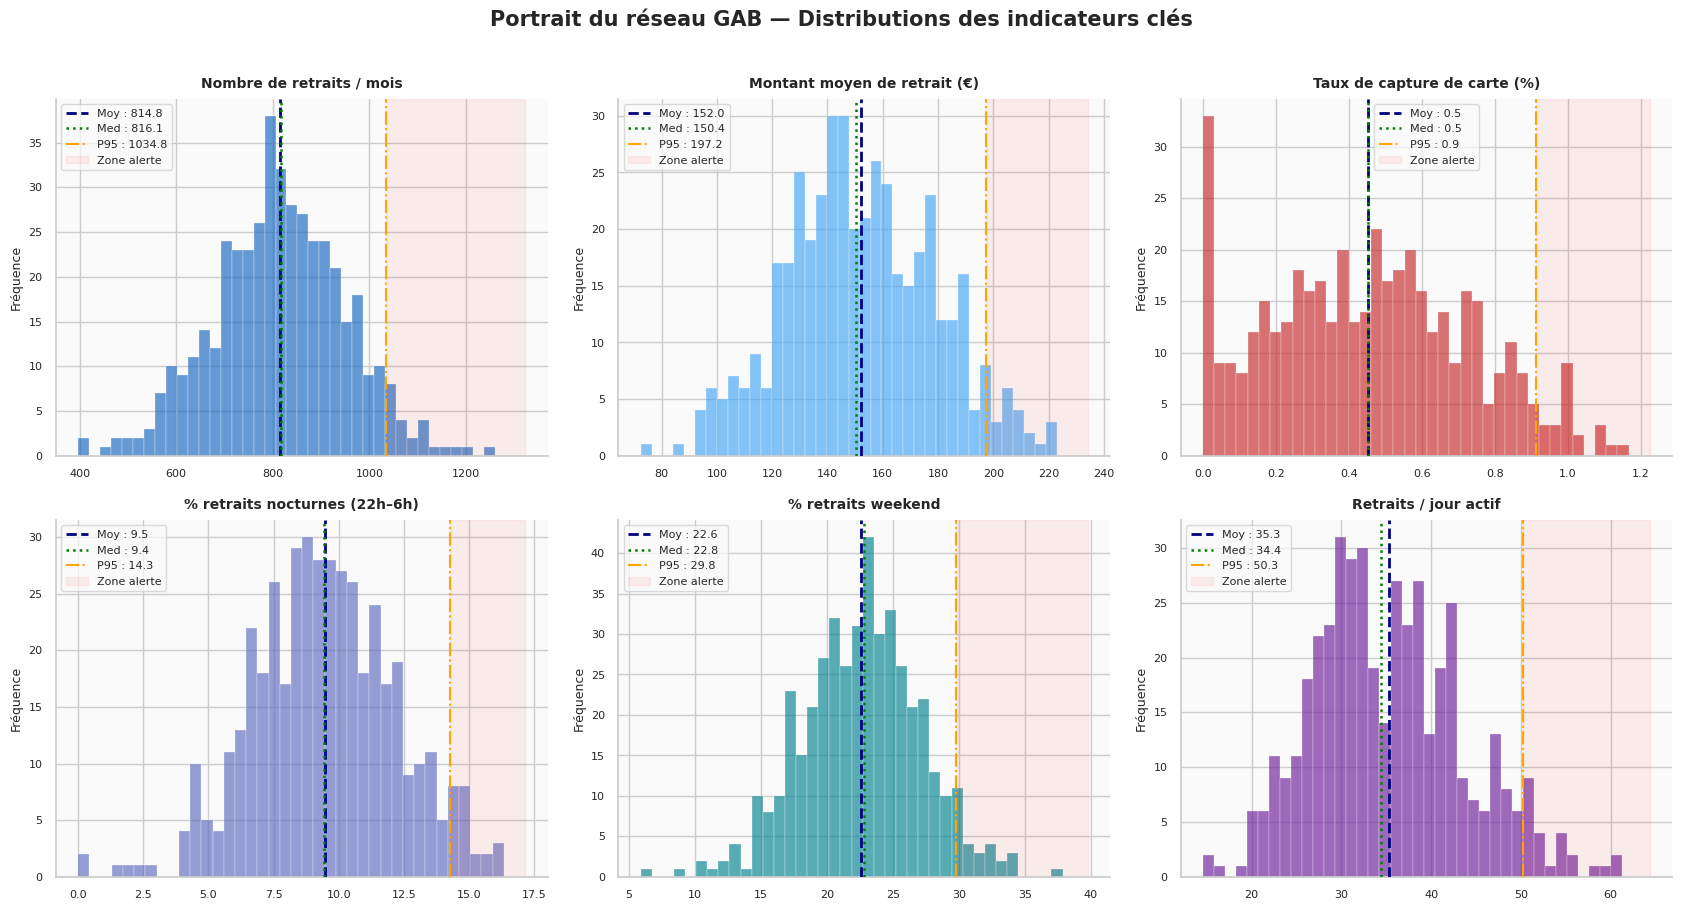

In [ ]:
# ── 5.2 Distributions des indicateurs clés ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Portrait du réseau GAB — Distributions des indicateurs clés',
             fontsize=15, fontweight='bold', y=1.01)

variables = [
    ('ret_nb',            'Nombre de retraits / mois',      BLEU_BANQUE),
    ('ret_montant_moyen', 'Montant moyen de retrait (€)',   BLEU_CLAIR),
    ('taux_capture_pct',  'Taux de capture de carte (%)',   ROUGE_ALERTE),
    ('ret_pct_nuit',      '% retraits nocturnes (22h–6h)',  '#5C6BC0'),
    ('ret_pct_weekend',   '% retraits weekend',             '#00838F'),
    ('intensite_retrait', 'Retraits / jour actif',          '#6A1B9A'),
]

for ax, (col, titre, couleur) in zip(axes.flatten(), variables):
    data = normaux[col].dropna()
    mu, med, p95 = data.mean(), data.median(), data.quantile(0.95)

    ax.hist(data, bins=38, color=couleur, alpha=0.65, edgecolor='white', linewidth=0.3)
    ax.axvline(mu,  color='navy',   lw=2.0, ls='--', label='Moy : {:.1f}'.format(mu),  zorder=5)
    ax.axvline(med, color='green',  lw=1.8, ls=':',  label='Med : {:.1f}'.format(med), zorder=5)
    ax.axvline(p95, color='orange', lw=1.5, ls='-.',  label='P95 : {:.1f}'.format(p95), zorder=5)
    ax.axvspan(p95, data.max()*1.05, alpha=0.06, color='red', label='Zone alerte')

    ax.set_title(titre, fontweight='bold', fontsize=10, pad=8)
    ax.set_ylabel('Fréquence', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('01_distributions_reseau.png', dpi=150, bbox_inches='tight')
plt.show()

display(HTML('''
<div style="background:#E8F5E9; border-left:4px solid #2E7D32; padding:10px 14px; border-radius:4px; margin:8px 0;">
  💡 <b>Lecture :</b> La zone rouge (P95+) marque le seuil naturel au-delà duquel un GAB devient "hors normes".
  Les GAB dans cette zone sur plusieurs indicateurs simultanément sont les candidats à l'investigation.
</div>
'''))

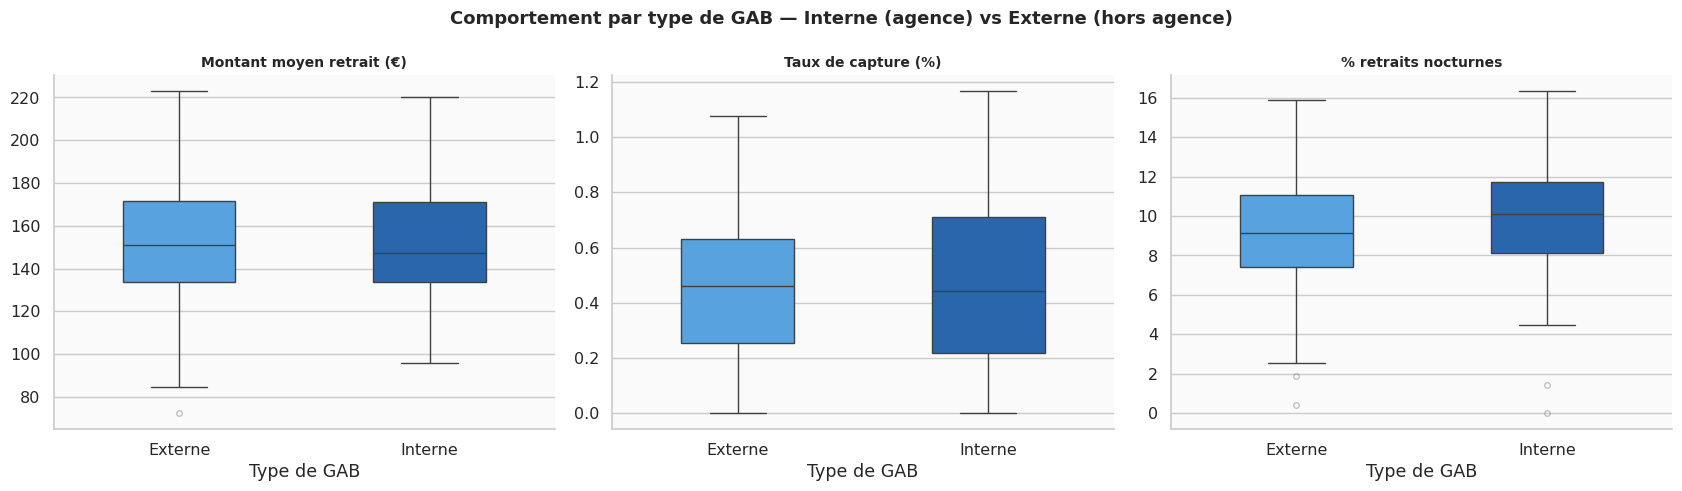

In [ ]:
# ── 5.3 Comparaison Interne vs Externe & analyse temporelle ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Comportement par type de GAB — Interne (agence) vs Externe (hors agence)',
             fontsize=13, fontweight='bold')

metriques = [
    ('ret_montant_moyen', 'Montant moyen retrait (€)'),
    ('taux_capture_pct',  'Taux de capture (%)'),
    ('ret_pct_nuit',      '% retraits nocturnes'),
]
palette = {'Interne': BLEU_BANQUE, 'Externe': BLEU_CLAIR, 'Inconnu': GRIS_FOND}

for ax, (col, titre) in zip(axes, metriques):
    types_presents = normaux['type_gab_e_i'].unique()
    pal = {k: v for k, v in palette.items() if k in types_presents}
    sns.boxplot(data=normaux, x='type_gab_e_i', y=col, ax=ax, palette=pal,
                width=0.45, flierprops={'marker':'o', 'alpha':0.3, 'markersize':4})
    ax.set_title(titre, fontweight='bold', fontsize=10)
    ax.set_xlabel('Type de GAB')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('02_boxplots_type_gab.png', dpi=150, bbox_inches='tight')
plt.show()

display(HTML('''
<div style="background:#FFF3E0; border-left:4px solid #E65100; padding:10px 14px; border-radius:4px; margin:8px 0;">
  ⚠️ <b>Important :</b> Les GAB Internes et Externes ont des profils naturellement différents.
  Le modèle en tient compte : une anomalie n'est évaluée qu'<b>en comparaison avec son propre type</b>.
</div>
'''))

---
## 6. 🔵 Clustering — Familles de comportements GAB

<div style="background: #EDE7F6; border-left: 4px solid #6A1B9A; padding: 12px 16px; border-radius: 4px;">
  <b>🎯 Objectif :</b> Avant de chercher les anomalies, regrouper les GAB en <b>familles comportementales homogènes</b>.<br>
  Cela permet de comparer chaque GAB à ses <b>pairs naturels</b>, et non à l'ensemble du réseau.
</div>

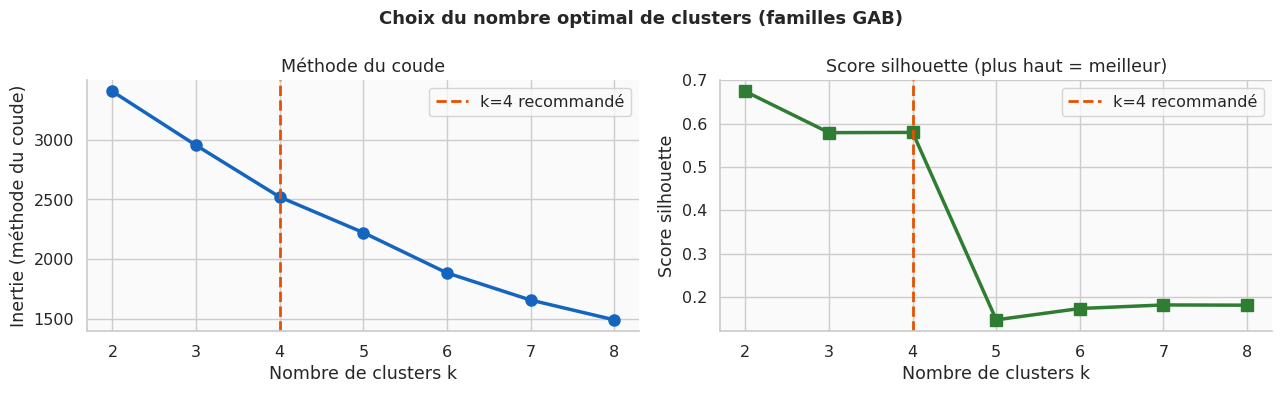

✅ Nombre de clusters retenu : 4


In [ ]:
# ── 6.1 Préparation du clustering ──────────────────────────────────────────────
FEATURES_CLUSTER = [
    'ret_nb', 'ret_montant_moyen', 'ret_montant_total',
    'ret_pct_nuit', 'ret_pct_weekend', 'intensite_retrait',
    'taux_capture_pct', 'concentration_reseau', 'cv_montant',
]

X_cluster = df[FEATURES_CLUSTER].fillna(0).values
scaler_cl = StandardScaler()
X_cluster_scaled = scaler_cl.fit_transform(X_cluster)

# ── 6.2 Choix du nombre de clusters (méthode du coude) ────────────────────────
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels, sample_size=min(500, len(df))))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Choix du nombre optimal de clusters (familles GAB)', fontsize=13, fontweight='bold')

axes[0].plot(list(K_range), inertias, 'o-', color=BLEU_BANQUE, lw=2.5, markersize=8)
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie (méthode du coude)')
axes[0].set_title('Méthode du coude')
axes[0].axvline(4, color=ORANGE_VIGILANCE, lw=2, ls='--', label='k=4 recommandé')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, 's-', color=VERT_NORMAL, lw=2.5, markersize=8)
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score silhouette')
axes[1].set_title('Score silhouette (plus haut = meilleur)')
axes[1].axvline(4, color=ORANGE_VIGILANCE, lw=2, ls='--', label='k=4 recommandé')
axes[1].legend()

plt.tight_layout()
plt.savefig('03_choix_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

N_CLUSTERS = 4
print('✅ Nombre de clusters retenu : {0}'.format(N_CLUSTERS))

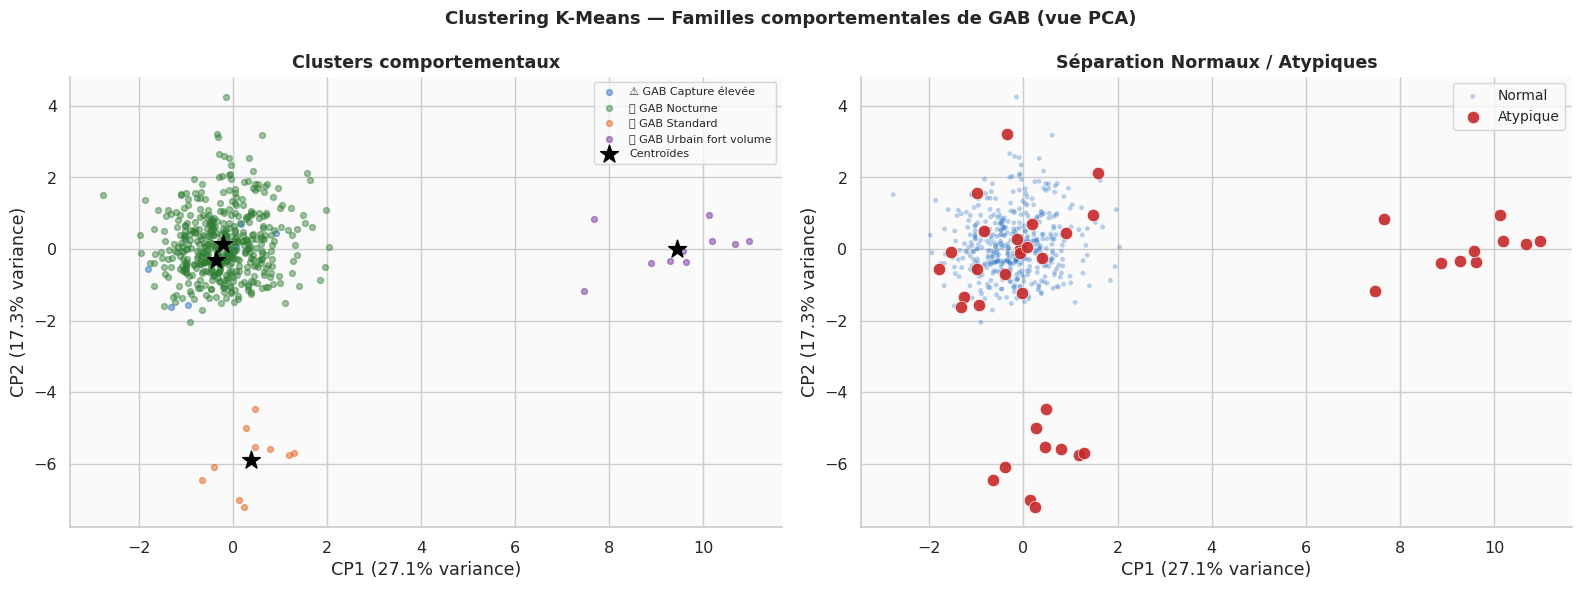


📋 Composition des clusters :


,Profil,Nb GAB,Retraits/mois,Montant moy (€),Taux capture (%),% Nuit
cluster,,,,,,
0,⚠️ GAB Capture élevée,10,831.100000,154.700000,11.200000,8.300000
1,🌙 GAB Nocturne,450,815.800000,151.900000,0.500000,10.200000
2,🏘️ GAB Standard,10,920.400000,530.600000,0.400000,9.800000
3,🏙️ GAB Urbain fort volume,10,2294.100000,151.100000,0.400000,9.600000


In [ ]:
# ── 6.3 Application du clustering ─────────────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Nommage automatique des clusters par profil dominant
profils_cluster = df.groupby('cluster')[FEATURES_CLUSTER].mean()

noms_clusters = {}
for idx, row in profils_cluster.iterrows():
    if row['ret_nb'] > profils_cluster['ret_nb'].quantile(0.75):
        nom = '🏙️ GAB Urbain fort volume'
    elif row['ret_pct_nuit'] > profils_cluster['ret_pct_nuit'].quantile(0.75):
        nom = '🌙 GAB Nocturne'
    elif row['taux_capture_pct'] > profils_cluster['taux_capture_pct'].quantile(0.75):
        nom = '⚠️ GAB Capture élevée'
    else:
        nom = '🏘️ GAB Standard'
    noms_clusters[idx] = nom

df['cluster_nom'] = df['cluster'].map(noms_clusters)

# ── Visualisation des clusters en PCA 2D ──────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Clustering K-Means — Familles comportementales de GAB (vue PCA)', fontsize=13, fontweight='bold')

# Clusters
for cl_id, couleur in enumerate(COULEUR_CLUSTERS[:N_CLUSTERS]):
    mask = df['cluster'] == cl_id
    axes[0].scatter(df[mask]['pca1'], df[mask]['pca2'],
                    c=couleur, alpha=0.45, s=18, label='{0}'.format(noms_clusters[cl_id]))
# Centroïdes
centroides_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroides_pca[:, 0], centroides_pca[:, 1],
                c='black', s=180, marker='*', zorder=5, label='Centroïdes')
axes[0].set_title('Clusters comportementaux', fontweight='bold')
axes[0].set_xlabel('CP1 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[0]*100))
axes[0].set_ylabel('CP2 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[1]*100))
axes[0].legend(fontsize=8, loc='best')

# Anomalies vs normaux
for lbl, mask, c, s, a in [
    ('Normal',   df['flag_atypique']==0, BLEU_BANQUE,   12, 0.3),
    ('Atypique', df['flag_atypique']==1, ROUGE_ALERTE,  80, 0.9),
]:
    axes[1].scatter(df[mask]['pca1'], df[mask]['pca2'], c=c, s=s, alpha=a,
                    label=lbl, edgecolors='white' if s > 30 else 'none', linewidths=0.5)
axes[1].set_title('Séparation Normaux / Atypiques', fontweight='bold')
axes[1].set_xlabel('CP1 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[0]*100))
axes[1].set_ylabel('CP2 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[1]*100))
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('04_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Composition des clusters :')
comp = df.groupby('cluster').agg(
    Nom=('cluster_nom','first'),
    Nb_GAB=('num_automate','count'),
    Retraits_moy=('ret_nb','mean'),
    Montant_moy=('ret_montant_moyen','mean'),
    Taux_capture_moy=('taux_capture_pct','mean'),
    Pct_nuit_moy=('ret_pct_nuit','mean'),
).round(1)
comp.columns = ['Profil','Nb GAB','Retraits/mois','Montant moy (€)','Taux capture (%)','% Nuit']
display(comp.style.background_gradient(subset=['Retraits/mois'], cmap='Blues')
              .background_gradient(subset=['Taux capture (%)'], cmap='Oranges'))

---
## 7. 🤖 Modélisation — Détection d'Anomalies (Isolation Forest)

<div style="background: #FCE4EC; border-left: 4px solid #C62828; padding: 12px 16px; border-radius: 4px;">

### Pourquoi l'Isolation Forest ?

| Modèle | Principe | Adapté ici ? |
|---|---|---|
| **Isolation Forest** ✅ | Isole les points rares par partitions aléatoires | ✅ Rapide · robuste · score continu |
| Local Outlier Factor | Densité locale vs voisins | ⚠️ Lent sur grands volumes |
| Z-score univarié | Écart à la moyenne par variable | ⚠️ Ne capte pas les combinaisons |
| One-Class SVM | Frontière autour des normaux | ⚠️ Difficile à paramétrer |

**L'Isolation Forest** est idéal car : il gère **50+ variables simultanément**, produit un **score de risque continu** (pas juste un label binaire), et détecte les **combinaisons subtiles** de signaux faibles invisibles à l'œil nu.

</div>

In [ ]:
# ── 7.1 Features pour le modèle ───────────────────────────────────────────────
FEATURES_MODELE = [
    # Volumes
    'ret_nb', 'ret_montant_total', 'intensite_retrait',
    # Montants
    'ret_montant_moyen', 'ret_montant_max', 'ret_montant_stddev', 'cv_montant',
    # Capture
    'taux_capture_pct', 'ratio_capture', 'cap_nb',
    # Temporalité
    'ret_pct_nuit', 'ret_pct_weekend', 'score_horaires_atypiques',
    # Réseau cartes
    'concentration_reseau',
    # Z-scores SQL (signal fort)
    'nb_zscore_eleves',
]
# Ajouter les volumes réseau disponibles
FEATURES_MODELE += [c for c in cols_reseau_nb if c in df.columns]

X = df[FEATURES_MODELE].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Matrice features : {0} lignes × {1} colonnes'.format(X_scaled.shape[0], X_scaled.shape[1]))
print('   Features sélectionnées :')
for i, f in enumerate(FEATURES_MODELE):
    print('   [{0:2d}] {1}'.format(i+1, f))

✅ Matrice features : 480 lignes × 30 colonnes
   Features sélectionnées :
   [ 1] ret_nb
   [ 2] ret_montant_total
   [ 3] intensite_retrait
   [ 4] ret_montant_moyen
   [ 5] ret_montant_max
   [ 6] ret_montant_stddev
   [ 7] cv_montant
   [ 8] taux_capture_pct
   [ 9] ratio_capture
   [10] cap_nb
   [11] ret_pct_nuit
   [12] ret_pct_weekend
   [13] score_horaires_atypiques
   [14] concentration_reseau
   [15] nb_zscore_eleves
   [16] nb_ope_reseau_CB
   [17] nb_ope_reseau_Visa
   [18] nb_ope_reseau_Mastercard
   [19] nb_ope_reseau_Interne
   [20] nb_ope_reseau_Franfinance
   [21] nb_ope_reseau_Accord
   [22] nb_ope_reseau_PostEpargne
   [23] nb_ope_reseau_JCB
   [24] nb_ope_reseau_Trionis
   [25] nb_ope_reseau_PPL
   [26] nb_ope_reseau_Configona
   [27] nb_ope_reseau_COS
   [28] nb_ope_reseau_Casino
   [29] nb_ope_reseau_Diners_et_Discovery
   [30] nb_ope_reseau_autres


In [ ]:
# ── 7.2 Entraînement du modèle ────────────────────────────────────────────────
modele = IsolationForest(
    n_estimators  = 250,
    contamination = 0.08,   # ~8% de GAB estimés atypiques
    max_features  = 0.8,
    random_state  = 42,
    n_jobs        = -1
)

df['label_if']   = modele.fit_predict(X_scaled)   # -1 = anomalie, +1 = normal
df['score_if']   = modele.score_samples(X_scaled)  # plus bas = plus anormal

# Score de risque normalisé [0, 1] pour la communication métier
s_min, s_max = df['score_if'].min(), df['score_if'].max()
df['score_risque'] = 1.0 - (df['score_if'] - s_min) / (s_max - s_min + 1e-9)

df['est_anomalie_if'] = (df['label_if'] == -1).astype(int)

# Signal combiné : IF + z-scores SQL
df['est_anomalie'] = ((df['est_anomalie_if'] == 1) | (df['nb_metriques_anormales'] >= 2)).astype(int)

n_anom = df['est_anomalie'].sum()
print('🚨 GAB atypiques détectés : {0} / {1} ({2:.1f}%)'.format(
    n_anom, len(df), n_anom/len(df)*100))
print('   → dont {0} par Isolation Forest seul'.format(df['est_anomalie_if'].sum()))
print('   → dont {0} par z-scores SQL seuls (≥2 métriques)'.format(
    ((df['nb_metriques_anormales'] >= 2) & (df['est_anomalie_if'] == 0)).sum()))

🚨 GAB atypiques détectés : 116 / 480 (24.2%)
   → dont 39 par Isolation Forest seul
   → dont 77 par z-scores SQL seuls (≥2 métriques)


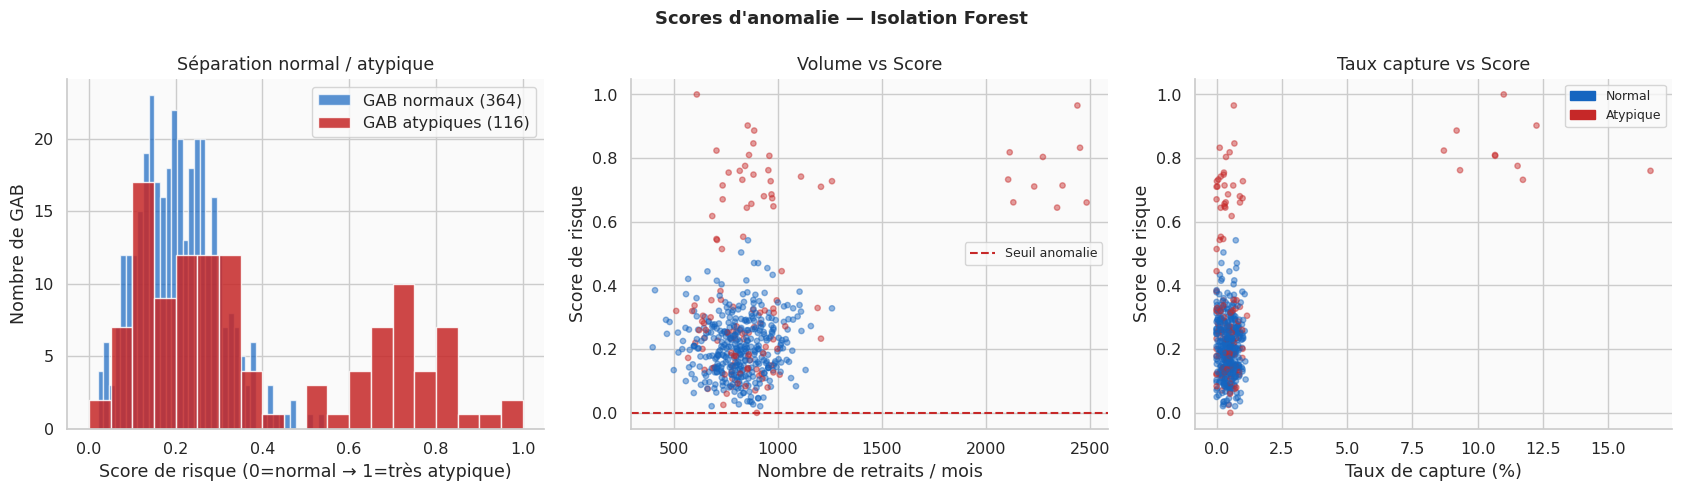

In [ ]:
# ── 7.3 Visualisation des scores ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Scores d\'anomalie — Isolation Forest', fontsize=13, fontweight='bold')

# Histogramme de séparation
ax = axes[0]
ax.hist(df[df['est_anomalie']==0]['score_risque'], bins=40,
        color=BLEU_BANQUE, alpha=0.7, label='GAB normaux ({0})'.format((df['est_anomalie']==0).sum()))
ax.hist(df[df['est_anomalie']==1]['score_risque'], bins=20,
        color=ROUGE_ALERTE, alpha=0.85, label='GAB atypiques ({0})'.format(n_anom))
ax.set_xlabel('Score de risque (0=normal → 1=très atypique)')
ax.set_ylabel('Nombre de GAB')
ax.set_title('Séparation normal / atypique')
ax.legend()

# Volume vs score
ax2 = axes[1]
couleurs_pts = [ROUGE_ALERTE if a else BLEU_BANQUE for a in df['est_anomalie']]
ax2.scatter(df['ret_nb'], df['score_risque'], c=couleurs_pts, alpha=0.45, s=15)
ax2.set_xlabel('Nombre de retraits / mois')
ax2.set_ylabel('Score de risque')
ax2.set_title('Volume vs Score')
ax2.axhline(df[df['est_anomalie']==1]['score_risque'].min(), color=ROUGE_ALERTE,
            lw=1.5, ls='--', label='Seuil anomalie')
ax2.legend(fontsize=9)

# Taux capture vs score
ax3 = axes[2]
ax3.scatter(df['taux_capture_pct'], df['score_risque'], c=couleurs_pts, alpha=0.45, s=15)
ax3.set_xlabel('Taux de capture (%)')
ax3.set_ylabel('Score de risque')
ax3.set_title('Taux capture vs Score')
patch_n = mpatches.Patch(color=BLEU_BANQUE,  label='Normal')
patch_a = mpatches.Patch(color=ROUGE_ALERTE, label='Atypique')
ax3.legend(handles=[patch_n, patch_a], fontsize=9)

plt.tight_layout()
plt.savefig('05_scores_anomalie.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. 🔎 Explication des Anomalies — Pourquoi ce GAB est-il atypique ?

<div style="background: #FCE4EC; border-left: 4px solid #C62828; padding: 12px 16px; border-radius: 4px;">
  ⭐ <b>C'est la section la plus importante pour les équipes métier.</b><br>
  Chaque anomalie est <b>expliquée en langage clair</b> avec les raisons précises de l'atypisme.
</div>

In [ ]:
# ── 8.1 Système d'explication automatique des anomalies ───────────────────────

REF = df[df['est_anomalie']==0]  # Référence = GAB normaux

def diagnostiquer_gab(row, ref=REF):
    """
    Retourne une liste de raisons métier expliquant l'atypisme d'un GAB.
    Chaque raison est un dict {signal, severite, valeur_gab, valeur_ref, emoji}.
    """
    raisons = []

    regles = [
        # (colonne, seuil_multiplicateur_ref, label_metier, emoji, direction)
        ('taux_capture_pct',   3.0, 'Taux de capture anormalement élevé', '📸', 'haut'),
        ('ret_pct_nuit',       2.5, 'Activité nocturne excessive (22h-6h)', '🌙', 'haut'),
        ('ret_pct_weekend',    1.8, 'Suractivité weekend anormale', '🗓️', 'haut'),
        ('ret_nb',             2.2, 'Volume de retraits anormalement élevé', '📈', 'haut'),
        ('ret_montant_moyen',  2.2, 'Montants moyens suspects (gros retraits)', '💶', 'haut'),
        ('cv_montant',         2.5, 'Dispersion des montants atypique', '📊', 'haut'),
        ('concentration_reseau', 1.8, 'Concentration anormale sur un réseau de cartes', '🃏', 'haut'),
        ('intensite_retrait',  2.2, 'Intensité journalière hors norme', '⚡', 'haut'),
        ('ret_nb',             0.3, 'Volume de retraits anormalement bas', '📉', 'bas'),
    ]

    for col, seuil_mult, label, emoji, direction in regles:
        if col not in row.index:
            continue
        val_gab = row[col]
        val_ref = ref[col].median()
        if val_ref == 0:
            continue
        ratio = val_gab / val_ref
        if direction == 'haut' and ratio >= seuil_mult:
            sev = '🔴 CRITIQUE' if ratio >= seuil_mult * 1.5 else '🟠 ÉLEVÉ'
            raisons.append({'signal': label, 'emoji': emoji, 'sev': sev,
                           'val_gab': val_gab, 'val_ref': val_ref, 'ratio': ratio})
        elif direction == 'bas' and ratio <= seuil_mult:
            raisons.append({'signal': label, 'emoji': emoji, 'sev': '🟡 NOTABLE',
                           'val_gab': val_gab, 'val_ref': val_ref, 'ratio': ratio})

    # Vérif z-scores SQL
    if row.get('nb_metriques_anormales', 0) >= 3:
        raisons.append({'signal': 'Cumul de métriques statistiquement anormales (z-score SQL)',
                       'emoji': '📐', 'sev': '🔴 CRITIQUE',
                       'val_gab': row.get('nb_metriques_anormales', 0), 'val_ref': 0, 'ratio': None})

    raisons.sort(key=lambda x: ('CRITIQUE' not in x['sev'], 'ÉLEVÉ' not in x['sev']))
    return raisons


# Appliquer à tous les GAB atypiques
anomalies = df[df['est_anomalie']==1].copy()
anomalies['diagnostic'] = anomalies.apply(diagnostiquer_gab, axis=1)
anomalies['nb_signaux']  = anomalies['diagnostic'].apply(len)
anomalies['signal_principal'] = anomalies['diagnostic'].apply(
    lambda r: r[0]['signal'] if r else 'Combinaison de signaux faibles'
)

print('✅ Diagnostic généré pour {0} GAB atypiques'.format(len(anomalies)))
print('\n📊 Signaux principaux les plus fréquents :')
print(anomalies['signal_principal'].value_counts().to_string())

✅ Diagnostic généré pour 116 GAB atypiques

📊 Signaux principaux les plus fréquents :
signal_principal
Combinaison de signaux faibles                                76
Cumul de métriques statistiquement anormales (z-score SQL)    15
Taux de capture anormalement élevé                            10
Activité nocturne excessive (22h-6h)                           7
Montants moyens suspects (gros retraits)                       6
Intensité journalière hors norme                               2


In [ ]:
# ── 8.2 Top 15 GAB atypiques avec diagnostic ───────────────────────────────────
top15 = anomalies.nlargest(15, 'score_risque')[[
    'num_automate','cluster_nom','score_risque','ret_nb',
    'ret_montant_moyen','taux_capture_pct','ret_pct_nuit',
    'ret_pct_weekend','signal_principal','nb_signaux'
]].reset_index(drop=True)
top15.index += 1
top15.columns = ['Automate','Cluster','Score risque','Nb retraits',
                  'Montant moy (€)','Taux capture (%)','% Nuit','% Weekend',
                  'Signal principal','Nb signaux']

display(HTML('<h4 style="color:#C62828;">🚨 TOP 15 — GAB les plus atypiques (avec motif)</h4>'))
display(top15.style
    .background_gradient(subset=['Score risque'], cmap='Reds')
    .background_gradient(subset=['Taux capture (%)'], cmap='Oranges')
    .background_gradient(subset=['% Nuit'], cmap='Purples')
    .format({
        'Score risque'   : '{:.3f}',
        'Taux capture (%)': '{:.2f}',
        'Montant moy (€)': '{:.0f}',
        '% Nuit'         : '{:.1f}',
        '% Weekend'      : '{:.1f}',
        'Nb retraits'    : '{:.0f}',
    })
)

,Automate,Cluster,Score risque,Nb retraits,Montant moy (€),Taux capture (%),% Nuit,% Weekend,Signal principal,Nb signaux
1,ANOM_CAP_005,⚠️ GAB Capture élevée,1.000,609,162,11.00,5.7,17.5,Taux de capture anormalement élevé,1
2,ANOM_VOL_027,🏙️ GAB Urbain fort volume,0.965,2439,143,0.66,16.3,27.4,Cumul de métriques statistiquement anormales (z-score SQL),3
3,ANOM_CAP_001,⚠️ GAB Capture élevée,0.902,854,186,12.25,12.5,24.0,Taux de capture anormalement élevé,1
4,ANOM_CAP_004,⚠️ GAB Capture élevée,0.887,885,141,9.19,10.9,17.4,Taux de capture anormalement élevé,1
5,ANOM_MON_039,🏘️ GAB Standard,0.846,881,495,0.68,6.8,25.1,Cumul de métriques statistiquement anormales (z-score SQL),2
6,ANOM_VOL_020,🏙️ GAB Urbain fort volume,0.833,2452,122,0.12,10.8,16.2,Cumul de métriques statistiquement anormales (z-score SQL),3
7,ANOM_CAP_000,⚠️ GAB Capture élevée,0.824,704,202,8.70,9.4,25.1,Taux de capture anormalement élevé,2
8,ANOM_VOL_021,🏙️ GAB Urbain fort volume,0.818,2114,116,0.50,6.1,19.8,Cumul de métriques statistiquement anormales (z-score SQL),3
9,ANOM_CAP_009,⚠️ GAB Capture élevée,0.810,860,176,10.66,8.5,21.5,Taux de capture anormalement élevé,2
10,ANOM_CAP_006,⚠️ GAB Capture élevée,0.807,958,136,10.67,6.0,24.7,Taux de capture anormalement élevé,1


In [ ]:
# ── 8.3 Fiche détaillée du GAB le plus atypique ────────────────────────────────
gab_row  = anomalies.nlargest(1, 'score_risque').iloc[0]
gab_id   = gab_row['num_automate']
diag     = diagnostiquer_gab(gab_row)

# Affichage HTML de la fiche
html_fiche  = '''
<div style="border: 2px solid #C62828; border-radius: 10px; padding: 20px; margin: 10px 0;
            background: linear-gradient(to right, #FFF8F8, white);">
  <h3 style="color:#C62828; margin-top:0;">📋 Fiche Anomalie — {gab_id}</h3>
  <div style="display:flex; gap:15px; flex-wrap:wrap; margin-bottom:15px;">
    <div style="background:#FFEBEE; padding:10px 15px; border-radius:6px;">
      <b>Score de risque</b><br><span style="font-size:1.8em; color:#C62828; font-weight:bold;">{score:.3f}/1.000</span>
    </div>
    <div style="background:#FFF3E0; padding:10px 15px; border-radius:6px;">
      <b>Cluster</b><br><span style="font-size:1.1em;">{cluster}</span>
    </div>
    <div style="background:#E8F5E9; padding:10px 15px; border-radius:6px;">
      <b>Type</b><br><span style="font-size:1.1em;">{type_gab}</span>
    </div>
    <div style="background:#E3F2FD; padding:10px 15px; border-radius:6px;">
      <b>Nb signaux</b><br><span style="font-size:1.8em; color:#1565C0; font-weight:bold;">{nb_sig}</span>
    </div>
  </div>
  <h4 style="color:#333; margin-bottom:8px;">🔍 Raisons de l'atypisme :</h4>
  <table style="width:100%; border-collapse:collapse;">
    <tr style="background:#ECEFF1; font-weight:bold;">
      <th style="padding:8px; text-align:left;">Signal</th>
      <th style="padding:8px;">Sévérité</th>
      <th style="padding:8px;">Valeur GAB</th>
      <th style="padding:8px;">Réseau normal</th>
      <th style="padding:8px;">Ratio</th>
    </tr>
'''.format(
    gab_id=gab_id,
    score=gab_row['score_risque'],
    cluster=gab_row.get('cluster_nom', 'N/A'),
    type_gab=gab_row.get('type_gab_e_i', 'N/A'),
    nb_sig=len(diag)
)

for d in diag:
    bg = '#FFEBEE' if 'CRITIQUE' in d['sev'] else '#FFF3E0' if 'ÉLEVÉ' in d['sev'] else '#FFFDE7'
    ratio_txt = '×{:.1f}'.format(d['ratio']) if d['ratio'] else 'N/A'
    html_fiche += '''
    <tr style="background:{bg}; border-bottom:1px solid #ddd;">
      <td style="padding:8px;">{emoji} {signal}</td>
      <td style="padding:8px; text-align:center; font-weight:bold;">{sev}</td>
      <td style="padding:8px; text-align:center;">{val:.2f}</td>
      <td style="padding:8px; text-align:center;">{ref:.2f}</td>
      <td style="padding:8px; text-align:center; font-weight:bold;">{ratio}</td>
    </tr>'''.format(
        bg=bg, emoji=d['emoji'], signal=d['signal'],
        sev=d['sev'], val=d['val_gab'], ref=d['val_ref'], ratio=ratio_txt
    )

html_fiche += '</table></div>'
display(HTML(html_fiche))

Signal,Sévérité,Valeur GAB,Réseau normal,Ratio
📸 Taux de capture anormalement élevé,🔴 CRITIQUE,11.00,0.46,×24.1


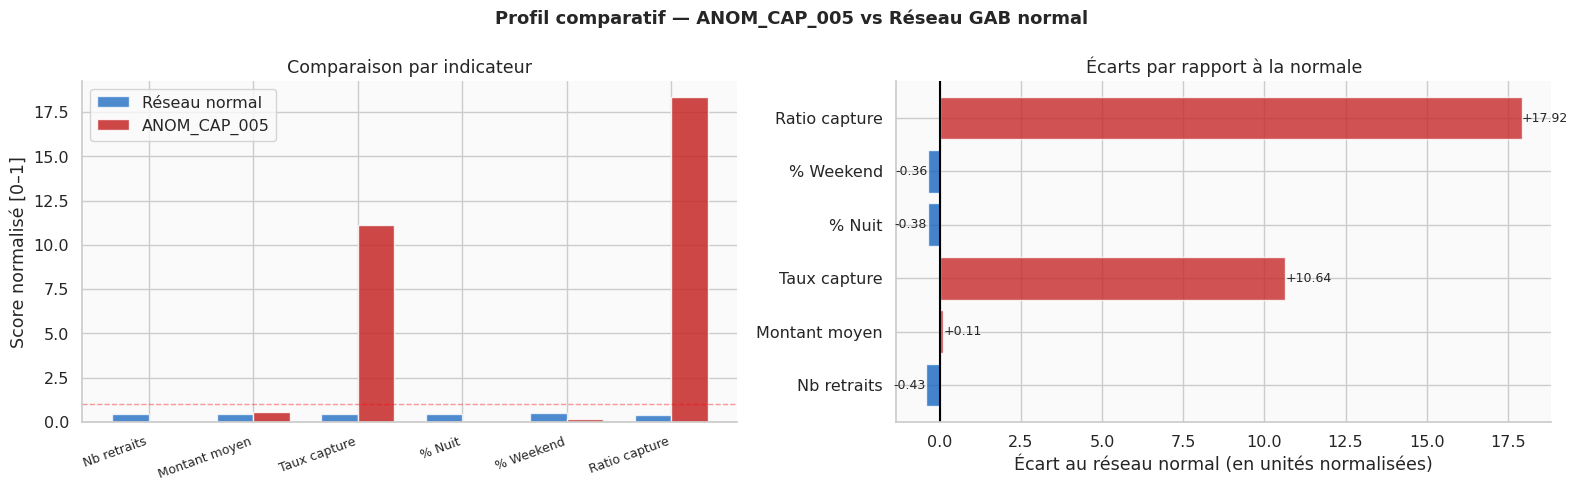

In [ ]:
# ── 8.4 Radar comparatif GAB atypique vs réseau ────────────────────────────────
cols_radar = ['ret_nb','ret_montant_moyen','taux_capture_pct',
              'ret_pct_nuit','ret_pct_weekend','ratio_capture']
labels_radar = ['Nb retraits','Montant moyen','Taux capture','% Nuit','% Weekend','Ratio capture']

ref_min = df[cols_radar].quantile(0.05).values
ref_max = df[cols_radar].quantile(0.95).values

def norm_radar(v, mn, mx):
    return [(vi - m) / (x - m + 1e-9) for vi, m, x in zip(v, mn, mx)]

# Barres comparatives — Matplotlib (compatible Dataiku)
vals_anom   = norm_radar(gab_row[cols_radar].values, ref_min, ref_max)
vals_normal = norm_radar(df[df['est_anomalie']==0][cols_radar].mean().values, ref_min, ref_max)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Profil comparatif — {0} vs Réseau GAB normal'.format(gab_id),
             fontsize=13, fontweight='bold')

x = np.arange(len(labels_radar))
w = 0.35
axes[0].bar(x - w/2, vals_normal, w, label='Réseau normal', color=BLEU_BANQUE,   alpha=0.75)
axes[0].bar(x + w/2, vals_anom,   w, label=gab_id,          color=ROUGE_ALERTE,  alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_radar, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Score normalisé [0–1]')
axes[0].set_title('Comparaison par indicateur')
axes[0].legend()
axes[0].axhline(1.0, color='red', lw=1, ls='--', alpha=0.4, label='Max réseau (P95)')

# Graphique d'écart
ecarts = np.array(vals_anom) - np.array(vals_normal)
couleurs_ecart = [ROUGE_ALERTE if e > 0 else BLEU_BANQUE for e in ecarts]
axes[1].barh(labels_radar, ecarts, color=couleurs_ecart, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set_xlabel('Écart au réseau normal (en unités normalisées)')
axes[1].set_title('Écarts par rapport à la normale')
for i, (val, lab) in enumerate(zip(ecarts, labels_radar)):
    axes[1].text(val + 0.01 * np.sign(val), i, '{0:+.2f}'.format(val),
                 va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('06_profil_gab_atypique.png', dpi=150, bbox_inches='tight')
plt.show()

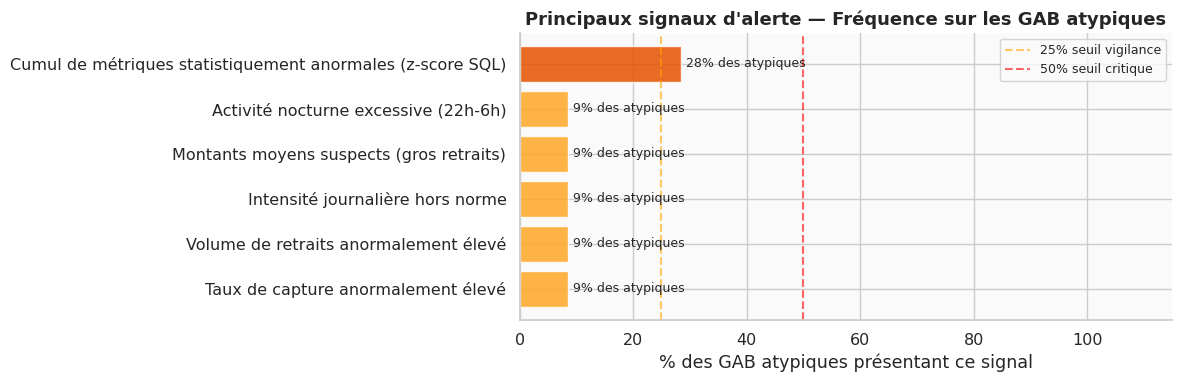

In [ ]:
# ── 8.5 Fréquence des signaux d'alerte sur l'ensemble des anomalies ────────────
from collections import Counter

tous_signaux = []
for diag_list in anomalies['diagnostic']:
    for d in diag_list:
        tous_signaux.append(d['signal'])

signaux_freq = pd.Series(Counter(tous_signaux)).sort_values(ascending=True)
pct_freq = signaux_freq / len(anomalies) * 100

fig, ax = plt.subplots(figsize=(12, max(4, len(signaux_freq)*0.5+1)))
couleurs_barres = [
    ROUGE_ALERTE if pct >= 50 else ORANGE_VIGILANCE if pct >= 25 else '#FFA726'
    for pct in pct_freq.values
]
bars = ax.barh(signaux_freq.index, pct_freq.values, color=couleurs_barres, alpha=0.85, edgecolor='white')
ax.axvline(25, color='orange', lw=1.5, ls='--', alpha=0.6, label='25% seuil vigilance')
ax.axvline(50, color='red',    lw=1.5, ls='--', alpha=0.6, label='50% seuil critique')
for bar, pct in zip(bars, pct_freq.values):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            '{:.0f}% des atypiques'.format(pct), va='center', fontsize=9)
ax.set_xlabel('% des GAB atypiques présentant ce signal')
ax.set_title('Principaux signaux d\'alerte — Fréquence sur les GAB atypiques',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('07_signaux_alerte_freq.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. 📅 Vue Annuelle — Consolidation par GAB

<div style="background: #E8EAF6; border-left: 4px solid #3949AB; padding: 12px 16px; border-radius: 4px;">
  <b>🎯 Problème résolu ici :</b> L'analyse mois par mois faisait apparaître plusieurs fois le même GAB.<br>
  Cette section crée une <b>vue annuelle unifiée</b> : chaque GAB n'apparaît qu'<b>une seule fois</b>,
  avec le compte de ses mois atypiques et la liste consolidée de ses signaux.
</div>

In [ ]:
from collections import Counter
import pandas as pd
import numpy as np

# ── 9.1 Agrégation annuelle ───────────────────────────────────────────────────

def signaux_consolides(group):
    """Consolide les signaux diagnostiqués sur tous les mois d'un GAB."""
    tous = []

    if 'diagnostic' not in group.columns:
        return 'Combinaison de signaux faibles'

    for diag_list in group['diagnostic']:
        if diag_list is None:
            continue
        if isinstance(diag_list, float) and pd.isna(diag_list):
            continue
        if not isinstance(diag_list, (list, tuple)):
            continue

        for d in diag_list:
            if isinstance(d, dict) and 'signal' in d:
                tous.append(d['signal'])

    if not tous:
        return 'Combinaison de signaux faibles'

    compte = Counter(tous)
    return ' | '.join(
        ['{0} ({1}×)'.format(signal, nb) for signal, nb in compte.most_common(3)]
    )


# ── Joindre les diagnostics à df ──────────────────────────────────────────────
df_with_diag = df.copy()
df_with_diag['diagnostic'] = None

for idx in anomalies.index:
    if idx in df_with_diag.index:
        df_with_diag.at[idx, 'diagnostic'] = anomalies.at[idx, 'diagnostic']


# ── Agrégation annuelle ───────────────────────────────────────────────────────
df_annuel = df_with_diag.groupby('num_automate').agg(
    annees_presentes      = ('annee', lambda x: sorted(x.dropna().unique().tolist())),
    nb_mois_analyses      = ('mois', 'count'),
    nb_mois_atypiques     = ('est_anomalie', 'sum'),
    score_risque_max      = ('score_risque', 'max'),
    score_risque_moyen    = ('score_risque', 'mean'),
    ret_nb_moyen          = ('ret_nb', 'mean'),
    ret_montant_moyen_moy = ('ret_montant_moyen', 'mean'),
    taux_capture_moy      = ('taux_capture_pct', 'mean'),
    ret_pct_nuit_moy      = ('ret_pct_nuit', 'mean'),
    ret_pct_weekend_moy   = ('ret_pct_weekend', 'mean'),
    cluster_principal     = ('cluster_nom', lambda x: x.mode().iloc[0] if not x.mode().empty else 'N/A'),
    type_gab              = ('type_gab_e_i', 'first'),
    longitude             = ('longitude', 'first'),
    latitude              = ('latitude', 'first'),
    code_postal           = ('code_postale_emplacement', 'first'),
).reset_index()


# ── Consolidation des signaux ────────────────────────────────────────────────
signaux_par_gab = (
    df_with_diag
    .groupby('num_automate')
    .apply(signaux_consolides)
    .reset_index(name='signaux_consolides')
)

df_annuel = df_annuel.merge(signaux_par_gab, on='num_automate', how='left')


# ── Catégorie d'atypicité ────────────────────────────────────────────────────
def categoriser_atypicite(row):
    if row['nb_mois_atypiques'] == 0:
        return '🟢 Aucun mois atypique'
    elif row['nb_mois_atypiques'] == 1:
        return '🟡 Isolé (1 mois)'
    elif row['nb_mois_atypiques'] <= 3:
        return '🟠 Récurrent (2-3 mois)'
    else:
        return '🔴 Persistant (4+ mois)'


df_annuel['categorie_atypicite'] = df_annuel.apply(categoriser_atypicite, axis=1)

df_annuel_atypiques = (
    df_annuel[df_annuel['nb_mois_atypiques'] > 0]
    .sort_values(['nb_mois_atypiques', 'score_risque_max'], ascending=[False, False])
    .reset_index(drop=True)
)

df_annuel_atypiques.index += 1


print('✅ Vue annuelle créée :')
print('   → {0} GAB distincts analysés'.format(len(df_annuel)))
print('   → {0} GAB avec au moins 1 mois atypique'.format(len(df_annuel_atypiques)))
print()
print("📊 Répartition par catégorie d'atypicité :")
print(df_annuel['categorie_atypicite'].value_counts().to_string())

✅ Vue annuelle créée :
   → 480 GAB distincts analysés
   → 116 GAB avec au moins 1 mois atypique

📊 Répartition par catégorie d'atypicité :
categorie_atypicite
🟢 Aucun mois atypique    364
🟡 Isolé (1 mois)         116


In [ ]:
# ── 9.2 Tableau annuel des GAB à investiguer ──────────────────────────────────
display(HTML('<h4 style="color:#C62828;">📋 Liste annuelle des GAB à investiguer (1 ligne = 1 GAB unique)</h4>'))

affichage = df_annuel_atypiques[[
    'num_automate','categorie_atypicite','nb_mois_atypiques','nb_mois_analyses',
    'score_risque_max','taux_capture_moy','ret_pct_nuit_moy',
    'cluster_principal','type_gab','signaux_consolides'
]].head(20)
affichage.columns = [
    'Automate','Catégorie','Mois atypiques','Mois analysés',
    'Score risque max','Taux capture moy (%)','% Nuit moy',
    'Cluster','Type','Principaux signaux'
]

def style_categorie(val):
    if 'Persistant' in str(val):
        return 'background-color: #FFCDD2; font-weight:bold;'
    elif 'Récurrent' in str(val):
        return 'background-color: #FFE0B2;'
    elif 'Isolé' in str(val):
        return 'background-color: #FFF9C4;'
    return ''

display(affichage.style
    .applymap(style_categorie, subset=['Catégorie'])
    .background_gradient(subset=['Score risque max'], cmap='Reds')
    .background_gradient(subset=['Mois atypiques'], cmap='Oranges')
    .format({
        'Score risque max'     : '{:.3f}',
        'Taux capture moy (%)': '{:.2f}',
        '% Nuit moy'           : '{:.1f}',
    })
)

,Automate,Catégorie,Mois atypiques,Mois analysés,Score risque max,Taux capture moy (%),% Nuit moy,Cluster,Type,Principaux signaux
1,ANOM_CAP_005,🟡 Isolé (1 mois),1,1,1.000,11.00,5.7,⚠️ GAB Capture élevée,Externe,Taux de capture anormalement élevé (1×)
2,ANOM_VOL_027,🟡 Isolé (1 mois),1,1,0.965,0.66,16.3,🏙️ GAB Urbain fort volume,Interne,Cumul de métriques statistiquement anormales (z-score SQL) (1×) | Volume de retraits anormalement élevé (1×) | Intensité journalière hors norme (1×)
3,ANOM_CAP_001,🟡 Isolé (1 mois),1,1,0.902,12.25,12.5,⚠️ GAB Capture élevée,Interne,Taux de capture anormalement élevé (1×)
4,ANOM_CAP_004,🟡 Isolé (1 mois),1,1,0.887,9.19,10.9,⚠️ GAB Capture élevée,Interne,Taux de capture anormalement élevé (1×)
5,ANOM_MON_039,🟡 Isolé (1 mois),1,1,0.846,0.68,6.8,🏘️ GAB Standard,Interne,Cumul de métriques statistiquement anormales (z-score SQL) (1×) | Montants moyens suspects (gros retraits) (1×)
6,ANOM_VOL_020,🟡 Isolé (1 mois),1,1,0.833,0.12,10.8,🏙️ GAB Urbain fort volume,Interne,Cumul de métriques statistiquement anormales (z-score SQL) (1×) | Volume de retraits anormalement élevé (1×) | Intensité journalière hors norme (1×)
7,ANOM_CAP_000,🟡 Isolé (1 mois),1,1,0.824,8.70,9.4,⚠️ GAB Capture élevée,Externe,Taux de capture anormalement élevé (1×) | Cumul de métriques statistiquement anormales (z-score SQL) (1×)
8,ANOM_VOL_021,🟡 Isolé (1 mois),1,1,0.818,0.50,6.1,🏙️ GAB Urbain fort volume,Externe,Cumul de métriques statistiquement anormales (z-score SQL) (1×) | Volume de retraits anormalement élevé (1×) | Intensité journalière hors norme (1×)
9,ANOM_CAP_009,🟡 Isolé (1 mois),1,1,0.810,10.66,8.5,⚠️ GAB Capture élevée,Externe,Taux de capture anormalement élevé (1×) | Cumul de métriques statistiquement anormales (z-score SQL) (1×)
10,ANOM_CAP_006,🟡 Isolé (1 mois),1,1,0.807,10.67,6.0,⚠️ GAB Capture élevée,Externe,Taux de capture anormalement élevé (1×)


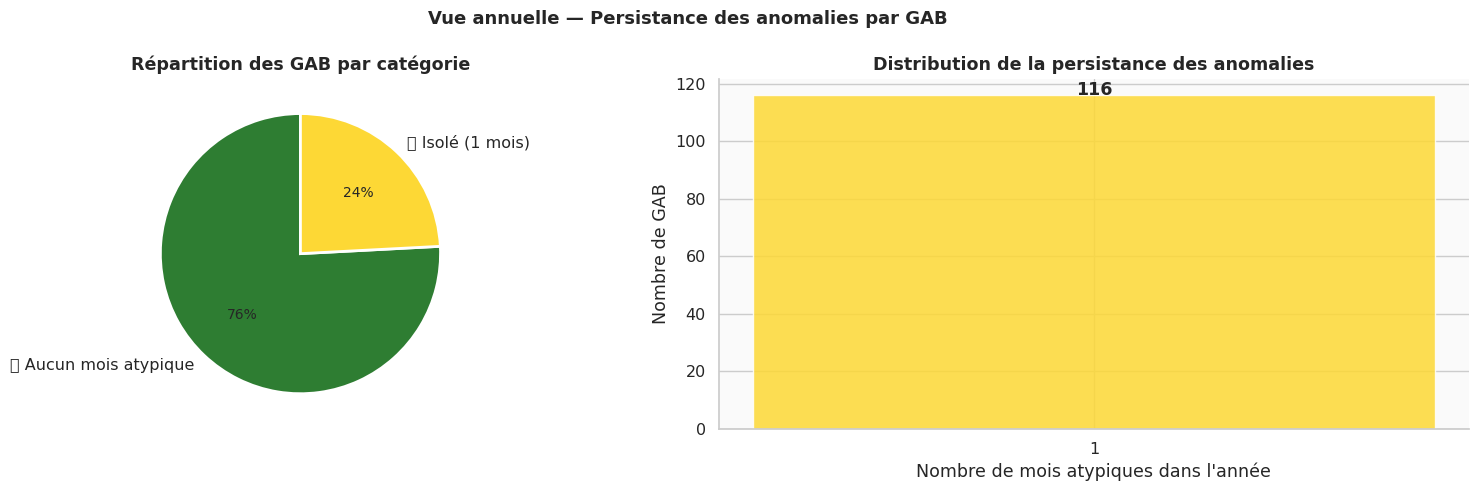

In [ ]:
# ── 9.3 Visualisation annuelle : mois atypiques par GAB ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Vue annuelle — Persistance des anomalies par GAB', fontsize=13, fontweight='bold')

# Répartition des catégories
cat_counts = df_annuel['categorie_atypicite'].value_counts()
couleurs_cat = {
    '🟢 Aucun mois atypique' : VERT_NORMAL,
    '🟡 Isolé (1 mois)'      : '#FDD835',
    '🟠 Récurrent (2-3 mois)': ORANGE_VIGILANCE,
    '🔴 Persistant (4+ mois)': ROUGE_ALERTE,
}
cats_ordered = ['🟢 Aucun mois atypique','🟡 Isolé (1 mois)','🟠 Récurrent (2-3 mois)','🔴 Persistant (4+ mois)']
cats_present = [c for c in cats_ordered if c in cat_counts.index]
vals_cat     = [cat_counts[c] for c in cats_present]
cols_cat     = [couleurs_cat[c] for c in cats_present]

wedges, texts, autotexts = axes[0].pie(
    vals_cat, labels=cats_present, colors=cols_cat,
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)
for at in autotexts:
    at.set_fontsize(10)
axes[0].set_title('Répartition des GAB par catégorie', fontweight='bold')

# Distribution du nombre de mois atypiques
nb_mois_dist = df_annuel[df_annuel['nb_mois_atypiques'] > 0]['nb_mois_atypiques'].value_counts().sort_index()
couleurs_barres = [
    ROUGE_ALERTE if m >= 4 else ORANGE_VIGILANCE if m >= 2 else '#FDD835'
    for m in nb_mois_dist.index
]
axes[1].bar(nb_mois_dist.index.astype(str), nb_mois_dist.values,
            color=couleurs_barres, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Nombre de mois atypiques dans l\'année')
axes[1].set_ylabel('Nombre de GAB')
axes[1].set_title('Distribution de la persistance des anomalies', fontweight='bold')
for i, v in enumerate(nb_mois_dist.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('08_vue_annuelle.png', dpi=150, bbox_inches='tight')
plt.show()

display(HTML('''
<div style="background:#E8EAF6; border-left:4px solid #3949AB; padding:10px 14px; border-radius:4px; margin:8px 0;">
  💡 <b>Priorité d'investigation :</b> Les GAB <span style="color:#C62828; font-weight:bold;">Persistants (4+ mois)</span>
  indiquent un problème structurel à traiter en urgence. Les <span style="color:#E65100; font-weight:bold;">Récurrents</span>
  méritent une surveillance renforcée. Les <span style="color:#F9A825; font-weight:bold;">Isolés</span> peuvent être
  contextuels (événement ponctuel) mais doivent être vérifiés.
</div>
'''))

---
## 10. 🗺️ Analyse Géographique — Localisation des Anomalies

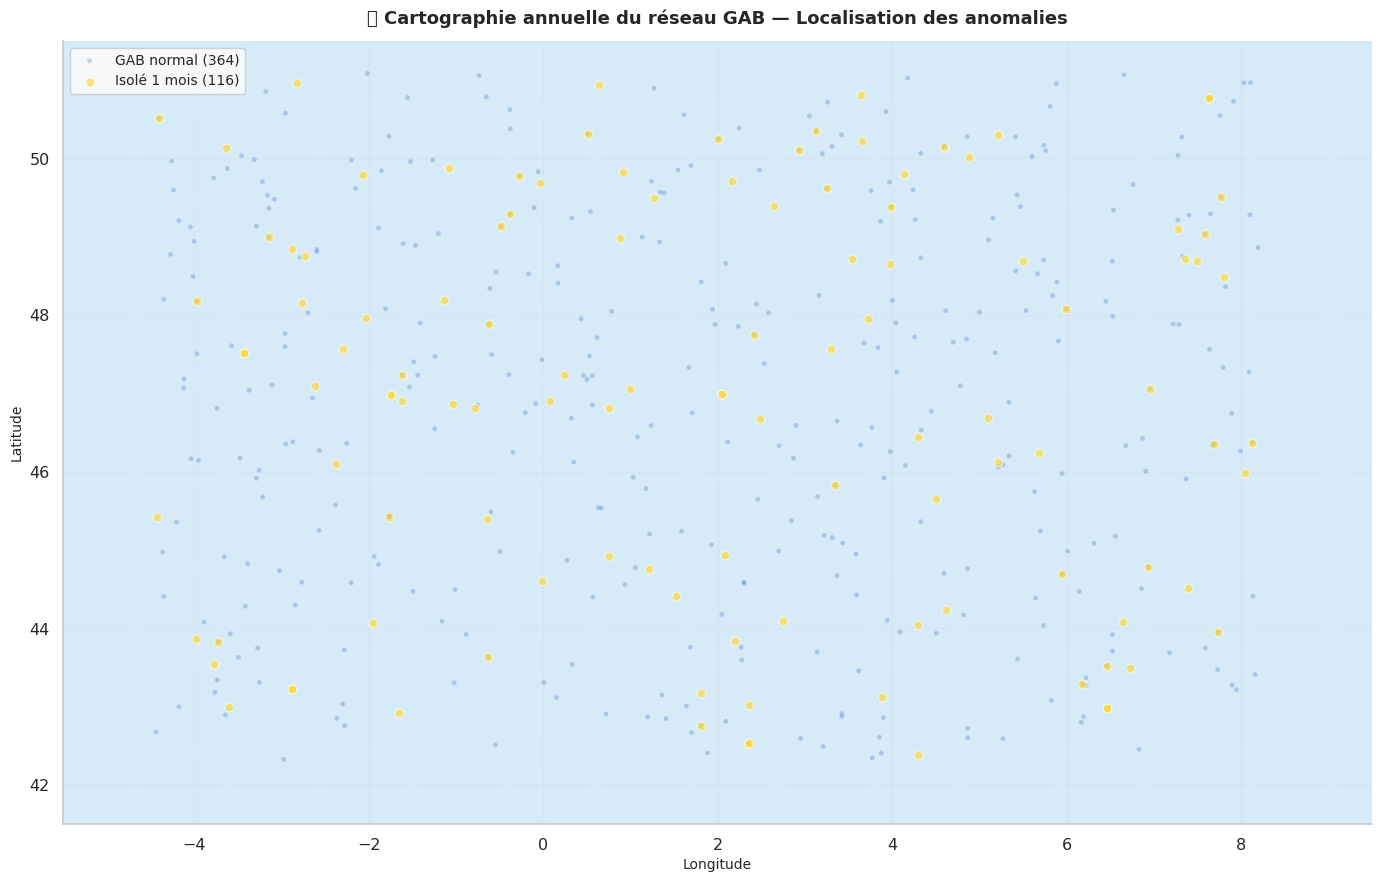

In [ ]:
# ── 10.1 Carte matplotlib (compatible Dataiku sans Plotly) ─────────────────────
df_geo = df_annuel.copy()
df_geo['statut'] = df_geo['nb_mois_atypiques'].apply(
    lambda x: '🔴 Persistant' if x >= 4 else '🟠 Récurrent' if x >= 2 else '🟡 Isolé' if x == 1 else '🟢 Normal'
)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#D6EAF8')

config_statuts = [
    ('🟢 Normal',     BLEU_BANQUE,      12,  0.25, 'GAB normal ({0})'),
    ('🟡 Isolé',      '#FDD835',        40,  0.65, 'Isolé 1 mois ({0})'),
    ('🟠 Récurrent',  ORANGE_VIGILANCE, 80,  0.80, 'Récurrent 2-3 mois ({0})'),
    ('🔴 Persistant', ROUGE_ALERTE,    160,  0.95, 'Persistant 4+ mois ({0})'),
]

for statut, couleur, taille, alpha, label_fmt in config_statuts:
    mask = df_geo['statut'] == statut
    if mask.sum() == 0:
        continue
    subset = df_geo[mask]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        c=couleur, s=taille, alpha=alpha,
        edgecolors='white' if taille > 20 else 'none',
        linewidths=0.8, zorder=int(taille/10),
        label=label_fmt.format(mask.sum())
    )

# Annotations pour les persistants
persistants = df_geo[df_geo['statut'] == '🔴 Persistant'].nlargest(5, 'score_risque_max')
for _, row in persistants.iterrows():
    ax.annotate(
        row['num_automate'],
        xy=(row['longitude'], row['latitude']),
        xytext=(8, 8), textcoords='offset points',
        fontsize=7.5, color='#C62828', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#C62828', alpha=0.8)
    )

ax.set_xlim(-5.5, 9.5)
ax.set_ylim(41.5, 51.5)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_title('🗺️ Cartographie annuelle du réseau GAB — Localisation des anomalies',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('09_carte_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

display(HTML('''
<div style="background:#E3F2FD; border-left:4px solid #1565C0; padding:10px 14px; border-radius:4px; margin:8px 0;">
  🗺️ <b>Lecture de la carte :</b> La taille des points reflète la sévérité (persistance).
  Les 5 GAB les plus persistants sont annotés. Une concentration géographique d'anomalies
  peut indiquer un problème réseau local ou un contexte géographique particulier à investiguer.
</div>
'''))

---
## 11. ✅ Validation du Modèle — Sans étiquettes terrain

Sans vérité terrain, nous utilisons 3 méthodes de validation complémentaires :
1. **Séparation statistique** : les atypiques ont-ils des valeurs extrêmes ?
2. **Cohérence avec les z-scores SQL** : accord entre les deux approches ?
3. **Visualisation PCA** : les atypiques sont-ils aux marges du nuage ?

In [ ]:
# ── 11.1 Comparaison statistique Normaux vs Atypiques ─────────────────────────
cols_comp = ['ret_nb','ret_montant_moyen','taux_capture_pct','ret_pct_nuit','ret_pct_weekend']
labels_comp = ['Nb retraits','Montant moyen (€)','Taux capture (%)','% Nuit','% Weekend']

stats_n = df[df['est_anomalie']==0][cols_comp].agg(['mean','median']).round(2)
stats_a = df[df['est_anomalie']==1][cols_comp].agg(['mean','median']).round(2)

print('📊 Validation statistique : Normaux vs Atypiques')
print('=' * 70)
print('{:28s}  {:>10s}  {:>10s}  {:>8s}'.format('Indicateur','Normaux','Atypiques','Ratio'))
print('-' * 70)
for col, lab in zip(cols_comp, labels_comp):
    mn = stats_n.loc['mean', col]
    ma = stats_a.loc['mean', col]
    ratio = ma / mn if mn != 0 else float('nan')
    flag = '🔴' if ratio > 2 or ratio < 0.5 else '🟡' if ratio > 1.5 else '🟢'
    print('{flag} {lab:26s}  {mn:>10.2f}  {ma:>10.2f}  ×{ratio:.2f}'.format(
        flag=flag, lab=lab, mn=mn, ma=ma, ratio=ratio))
print('=' * 70)

# Cohérence avec z-scores SQL
print('\n🔬 Cohérence avec les z-scores SQL :')
df['nb_zscore_sql_eleves'] = (df[cols_zscore_sql].abs() > 2).sum(axis=1)
accord = df[(df['est_anomalie']==1) & (df['nb_zscore_sql_eleves'] >= 1)].shape[0]
total_anom = df['est_anomalie'].sum()
print('   → {0}/{1} anomalies IF confirmées par z-score SQL ({2:.0f}%)'.format(
    accord, total_anom, accord/max(total_anom,1)*100))
print('   → Anomalies subtiles (IF seul, invisibles au z-score) : {0}'.format(
    total_anom - accord))

📊 Validation statistique : Normaux vs Atypiques
Indicateur                       Normaux   Atypiques     Ratio
----------------------------------------------------------------------
🟢 Nb retraits                     814.77      956.61  ×1.17
🟢 Montant moyen (€)               151.44      186.34  ×1.23
🔴 Taux capture (%)                  0.46        1.33  ×2.89
🟢 % Nuit                            9.48       12.05  ×1.27
🟢 % Weekend                        22.64       22.81  ×1.01

🔬 Cohérence avec les z-scores SQL :
   → 41/116 anomalies IF confirmées par z-score SQL (35%)
   → Anomalies subtiles (IF seul, invisibles au z-score) : 75


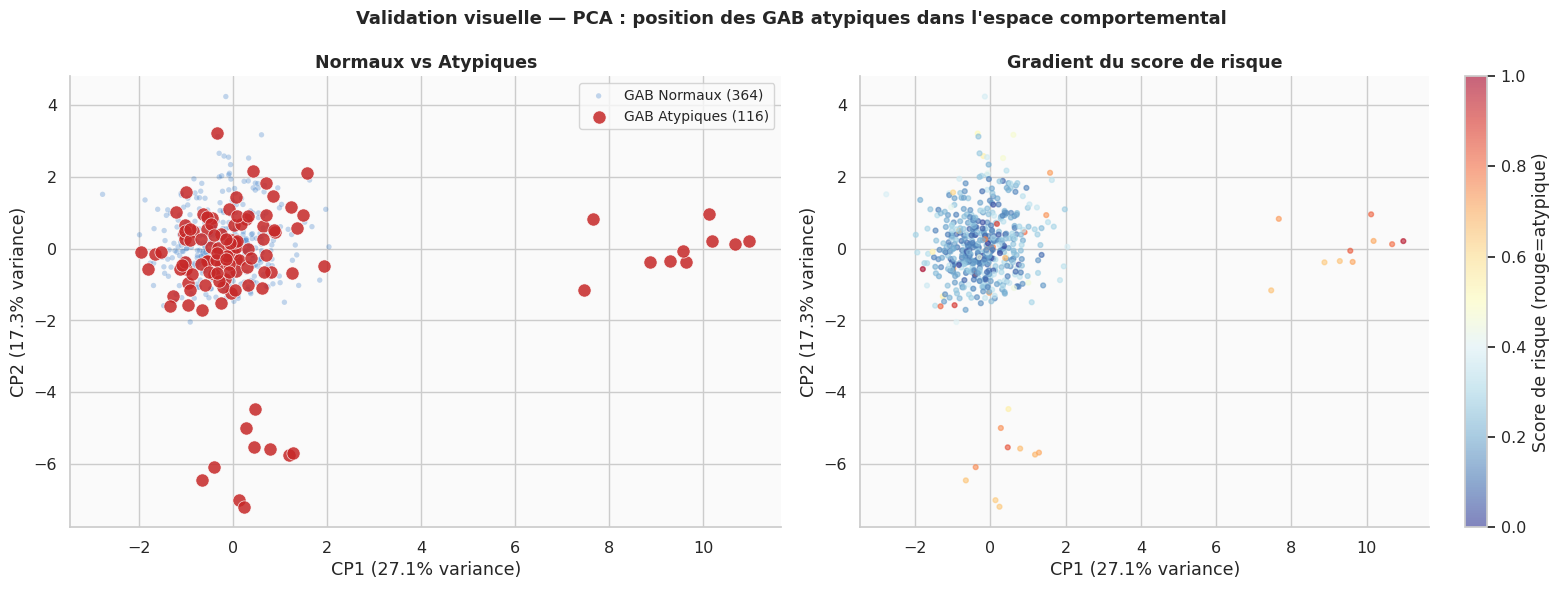

In [ ]:
# ── 11.2 Visualisation PCA finale ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Validation visuelle — PCA : position des GAB atypiques dans l\'espace comportemental',
             fontsize=13, fontweight='bold')

# Normaux vs Atypiques
for lbl, mask, c, s, a in [
    ('GAB Normaux ({0})'.format((df['est_anomalie']==0).sum()), df['est_anomalie']==0, BLEU_BANQUE,   15, 0.25),
    ('GAB Atypiques ({0})'.format(n_anom), df['est_anomalie']==1, ROUGE_ALERTE,  90, 0.85),
]:
    axes[0].scatter(df[mask]['pca1'], df[mask]['pca2'], c=c, s=s, alpha=a, label=lbl,
                    edgecolors='white' if s > 20 else 'none', linewidths=0.5)
axes[0].set_xlabel('CP1 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[0]*100))
axes[0].set_ylabel('CP2 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[1]*100))
axes[0].set_title('Normaux vs Atypiques', fontweight='bold')
axes[0].legend(fontsize=10)

# Coloré par score de risque
sc = axes[1].scatter(df['pca1'], df['pca2'], c=df['score_risque'],
                     cmap='RdYlBu_r', s=12, alpha=0.6, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label='Score de risque (rouge=atypique)')
axes[1].set_xlabel('CP1 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[0]*100))
axes[1].set_ylabel('CP2 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[1]*100))
axes[1].set_title('Gradient du score de risque', fontweight='bold')

plt.tight_layout()
plt.savefig('10_pca_validation.png', dpi=150, bbox_inches='tight')
plt.show()

display(HTML('''
<div style="background:#E8F5E9; border-left:4px solid #2E7D32; padding:10px 14px; border-radius:4px; margin:8px 0;">
  ✅ <b>Lecture :</b> Si les points rouges (atypiques) se situent bien en périphérie du nuage principal,
  le modèle identifie correctement des comportements marginaux. Un gradient progressif
  (bleu → rouge) confirme que le score de risque est bien ordonné.
</div>
'''))

---
## 12. 📤 Export & Tableau de Bord Final

In [ ]:
# ── 12.1 Tableau de bord synthèse ─────────────────────────────────────────────
n_total       = len(df_annuel)
n_persistants = (df_annuel['categorie_atypicite'].str.contains('Persistant')).sum()
n_recurrents  = (df_annuel['categorie_atypicite'].str.contains('Récurrent')).sum()
n_isoles      = (df_annuel['categorie_atypicite'].str.contains('Isolé')).sum()
n_normaux     = (df_annuel['categorie_atypicite'].str.contains('Aucun')).sum()

html_synthese = '''
<div style="border: 2px solid #1565C0; border-radius: 12px; padding: 25px; margin: 15px 0;
            background: linear-gradient(to bottom right, #E3F2FD, white);">
  <h2 style="color:#1565C0; margin-top:0; text-align:center;">📋 TABLEAU DE BORD — Détection d'Anomalies GAB</h2>
  <div style="display:flex; gap:12px; flex-wrap:wrap; justify-content:center; margin:20px 0;">
    <div style="background:#1565C0; color:white; padding:16px 22px; border-radius:8px; text-align:center; min-width:120px;">
      <div style="font-size:2em; font-weight:bold;">{total}</div><div style="font-size:0.8em; opacity:0.9;">GAB analysés</div>
    </div>
    <div style="background:{c_n}; color:white; padding:16px 22px; border-radius:8px; text-align:center; min-width:120px;">
      <div style="font-size:2em; font-weight:bold;">{norm}</div><div style="font-size:0.8em; opacity:0.9;">Normaux</div>
    </div>
    <div style="background:#F9A825; color:white; padding:16px 22px; border-radius:8px; text-align:center; min-width:120px;">
      <div style="font-size:2em; font-weight:bold;">{isol}</div><div style="font-size:0.8em; opacity:0.9;">Isolés (1 mois)</div>
    </div>
    <div style="background:{c_r}; color:white; padding:16px 22px; border-radius:8px; text-align:center; min-width:120px;">
      <div style="font-size:2em; font-weight:bold;">{recu}</div><div style="font-size:0.8em; opacity:0.9;">Récurrents 2-3 mois</div>
    </div>
    <div style="background:{c_p}; color:white; padding:16px 22px; border-radius:8px; text-align:center; min-width:120px;">
      <div style="font-size:2em; font-weight:bold;">{pers}</div><div style="font-size:0.8em; opacity:0.9;">Persistants 4+ mois</div>
    </div>
  </div>

  <h3 style="color:#C62828; margin-bottom:10px;">🔴 Principaux signaux détectés</h3>
  <ul style="margin:0; padding-left:20px;">
    <li>📸 <b>Taux de capture élevé</b> → suspicion de fraude ou de panne technique</li>
    <li>🌙 <b>Activité nocturne excessive</b> → comportement inhabituels hors horaires</li>
    <li>📈 <b>Volume anormal de retraits</b> → suractivité ou sous-activité inexpliquée</li>
    <li>💶 <b>Montants suspects</b> → gros retraits atypiques vs le réseau</li>
    <li>🃏 <b>Concentration réseau cartes</b> → anomalie de flux sur un type de carte</li>
  </ul>

  <h3 style="color:#1B5E20; margin-top:20px;">✅ Ce que le modèle apporte vs la surveillance manuelle</h3>
  <table style="width:100%; border-collapse:collapse; margin-top:8px;">
    <tr style="background:#C8E6C9; font-weight:bold;">
      <th style="padding:10px; text-align:left;">Avant (surveillance manuelle)</th>
      <th style="padding:10px; text-align:left;">Maintenant (modèle IA)</th>
    </tr>
    <tr style="border-bottom:1px solid #ddd;"><td style="padding:9px;">Seuils fixes sur 1-2 indicateurs</td><td style="padding:9px;">✅ Détection multi-dimensionnelle (50+ variables)</td></tr>
    <tr style="border-bottom:1px solid #ddd; background:#F1F8E9;"><td style="padding:9px;">Anomalies évidentes seulement</td><td style="padding:9px;">✅ Signaux faibles combinés invisibles à l'œil nu</td></tr>
    <tr style="border-bottom:1px solid #ddd;"><td style="padding:9px;">Même GAB répété chaque mois</td><td style="padding:9px;">✅ Vue annuelle unifiée — 1 GAB = 1 ligne</td></tr>
    <tr style="border-bottom:1px solid #ddd; background:#F1F8E9;"><td style="padding:9px;">Pas d'explication des alertes</td><td style="padding:9px;">✅ Motif explicite pour chaque anomalie détectée</td></tr>
    <tr style="background:#F1F8E9;"><td style="padding:9px;">Analyse rétrospective manuelle</td><td style="padding:9px;">✅ Exécution mensuelle automatique dans Dataiku</td></tr>
  </table>
</div>
'''.format(
    total=n_total, norm=n_normaux, isol=n_isoles, recu=n_recurrents, pers=n_persistants,
    c_n=VERT_NORMAL, c_r=ORANGE_VIGILANCE, c_p=ROUGE_ALERTE
)
display(HTML(html_synthese))

Avant (surveillance manuelle),Maintenant (modèle IA)
Seuils fixes sur 1-2 indicateurs,✅ Détection multi-dimensionnelle (50+ variables)
Anomalies évidentes seulement,✅ Signaux faibles combinés invisibles à l'œil nu
Même GAB répété chaque mois,✅ Vue annuelle unifiée — 1 GAB = 1 ligne
Pas d'explication des alertes,✅ Motif explicite pour chaque anomalie détectée
Analyse rétrospective manuelle,✅ Exécution mensuelle automatique dans Dataiku


In [ ]:
# ── 12.2 Export de la liste des GAB à investiguer ─────────────────────────────
export_cols = [
    'num_automate','categorie_atypicite','nb_mois_atypiques','nb_mois_analyses',
    'score_risque_max','score_risque_moyen','ret_nb_moyen','ret_montant_moyen_moy',
    'taux_capture_moy','ret_pct_nuit_moy','ret_pct_weekend_moy',
    'cluster_principal','type_gab','longitude','latitude','code_postal','signaux_consolides'
]

liste_investigation = df_annuel_atypiques[[c for c in export_cols if c in df_annuel_atypiques.columns]].copy()
liste_investigation = liste_investigation.round({
    'score_risque_max': 4, 'score_risque_moyen': 4,
    'taux_capture_moy': 3, 'ret_pct_nuit_moy': 2, 'ret_pct_weekend_moy': 2
})

# Export CSV
# liste_investigation.to_csv('gab_a_investiguer_annuel.csv', index=True, encoding='utf-8-sig')
# print('✅ Fichier exporté : gab_a_investiguer_annuel.csv')

# Export Dataiku
# import dataiku
# dataiku.Dataset('gab_a_investiguer_annuel').write_with_schema(liste_investigation)
# print('✅ Dataset Dataiku mis à jour : gab_a_investiguer_annuel')

print('📋 Liste finale des {0} GAB à investiguer :'.format(len(liste_investigation)))
display(liste_investigation.head(10))
print('\n💾 Pour exporter : décommenter les lignes to_csv ou dataiku.Dataset ci-dessus.')

📋 Liste finale des 116 GAB à investiguer :


,num_automate,categorie_atypicite,nb_mois_atypiques,nb_mois_analyses,score_risque_max,score_risque_moyen,ret_nb_moyen,ret_montant_moyen_moy,taux_capture_moy,ret_pct_nuit_moy,ret_pct_weekend_moy,cluster_principal,type_gab,longitude,latitude,code_postal,signaux_consolides
1,ANOM_CAP_005,🟡 Isolé (1 mois),1,1,1.0000,1.0000,609.339148,162.072629,10.996,5.75,17.45,⚠️ GAB Capture élevée,Externe,2.934000,50.104939,31000,Taux de capture anormalement élevé (1×)
2,ANOM_VOL_027,🟡 Isolé (1 mois),1,1,0.9653,0.9653,2439.256033,142.962971,0.661,16.34,27.37,🏙️ GAB Urbain fort volume,Interne,3.251239,49.618934,31000,Cumul de métriques statistiquement anormales (...
3,ANOM_CAP_001,🟡 Isolé (1 mois),1,1,0.9024,0.9024,854.153448,186.407500,12.250,12.55,23.97,⚠️ GAB Capture élevée,Interne,0.509849,50.314777,75001,Taux de capture anormalement élevé (1×)
4,ANOM_CAP_004,🟡 Isolé (1 mois),1,1,0.8866,0.8866,885.290172,141.489445,9.192,10.87,17.40,⚠️ GAB Capture élevée,Interne,-3.423141,47.520350,06000,Taux de capture anormalement élevé (1×)
5,ANOM_MON_039,🟡 Isolé (1 mois),1,1,0.8461,0.8461,881.386603,495.240719,0.683,6.80,25.09,🏘️ GAB Standard,Interne,7.686623,46.351153,69001,Cumul de métriques statistiquement anormales (...
6,ANOM_VOL_020,🟡 Isolé (1 mois),1,1,0.8327,0.8327,2451.868194,121.728161,0.121,10.83,16.21,🏙️ GAB Urbain fort volume,Interne,6.930294,44.783246,31000,Cumul de métriques statistiquement anormales (...
7,ANOM_CAP_000,🟡 Isolé (1 mois),1,1,0.8238,0.8238,704.010417,202.100766,8.704,9.45,25.05,⚠️ GAB Capture élevée,Externe,7.632751,50.772731,33000,Taux de capture anormalement élevé (1×) | Cumu...
8,ANOM_VOL_021,🟡 Isolé (1 mois),1,1,0.8182,0.8182,2113.750348,115.537302,0.501,6.08,19.78,🏙️ GAB Urbain fort volume,Externe,6.464337,42.978113,69001,Cumul de métriques statistiquement anormales (...
9,ANOM_CAP_009,🟡 Isolé (1 mois),1,1,0.8099,0.8099,860.417108,175.508619,10.662,8.50,21.46,⚠️ GAB Capture élevée,Externe,-0.377760,49.288937,33000,Taux de capture anormalement élevé (1×) | Cumu...
10,ANOM_CAP_006,🟡 Isolé (1 mois),1,1,0.8073,0.8073,958.226832,136.197438,10.667,5.98,24.69,⚠️ GAB Capture élevée,Externe,4.597307,50.152262,75001,Taux de capture anormalement élevé (1×)



💾 Pour exporter : décommenter les lignes to_csv ou dataiku.Dataset ci-dessus.


---
## 13. 📌 Conclusion & Prochaines Étapes

<div style="background: linear-gradient(135deg, #1a237e, #283593); color:white; padding:25px 30px; border-radius:10px; margin:10px 0;">

### 🎯 Ce que ce notebook accomplit

1. **Fiabilisation des données** — Détection et imputation des valeurs manquantes
2. **Clustering comportemental** — 4 familles de GAB identifiées (urbain fort volume, nocturne, standard, vigilance capture)
3. **Détection d'anomalies** — Isolation Forest sur 30+ variables, combiné aux z-scores SQL
4. **Explication des anomalies** — Motif précis pour chaque GAB atypique, en langage métier
5. **Vue annuelle unifiée** — Chaque GAB n'apparaît qu'une seule fois, avec la persistance de ses atypies
6. **Cartographie géographique** — Localisation des anomalies pour contexte territorial

</div>

### 🚀 Prochaines étapes recommandées

| Priorité | Action | Impact |
|---|---|---|
| 🔴 P1 | Validation métier : qualifier les GAB détectés (vrai/faux positif) | Améliore la précision du modèle |
| 🟠 P2 | Enrichir avec les données d'incidents déclarés et d'interventions techniques | Passage au semi-supervisé |
| 🟠 P3 | Intégrer le contexte géographique (densité population, commerces) | Réduit les faux positifs contextuels |
| 🟡 P4 | Mise en production Dataiku : exécution mensuelle automatique + alertes | Industrialisation |
| 🟡 P5 | Dashboard de suivi mensuel : évolution du parc atypique dans le temps | Pilotage continu |

---

> *« Un modèle n'est pas là pour remplacer l'expertise métier, mais pour l'amplifier.*  
> *Il voit ce que l'œil ne peut pas voir sur 500 automates simultanément,*  
> *et donne aux équipes les clés pour agir là où c'est vraiment utile. »*